## 1. Persiapan lingkungan dan eksplorasi data

In [1]:
# ==============================================================================
# FUNGSI CELL: Mengunduh dan menginstal pustaka-pustaka (libraries) utama yang 
# diperlukan untuk NLP, machine learning, FAISS vector search, interaksi GCP, 
# dan visualisasi data.
# ==============================================================================

# Menginstal dependensi Python yang dibutuhkan untuk proyek
# Perintah pip install menggunakan parameter '-q' (quiet) untuk menginstal secara senyap tanpa menampilkan log detail instalasi
!pip install -q \
  pandas \
  numpy>=2.0 \
  matplotlib==3.9.2 \
  seaborn==0.13.2 \
  scikit-learn>=1.6.0 \
  spacy==3.7.6 \
  sentence-transformers==3.3.1 \
  transformers==4.46.3 \
  torch>=2.11.0 \
  faiss-cpu==1.9.0 \
  fastapi>=0.124.1 \
  uvicorn>=0.34.0 \
  pdfplumber==0.11.4 \
  python-multipart>=0.0.18 \
  xgboost==2.1.3 \
  lightgbm==4.5.0 \
  optuna==4.1.0 \
  google-cloud-bigquery>=3.36.0 \
  google-cloud-storage==2.18.1 \
  pyarrow==17.00 \
  wordcloud==1.9.4

# Mengunduh model spaCy bahasa Inggris ('en_core_web_sm') untuk analisis teks NLP
# Parameter en_core_web_sm: Menentukan model bahasa kecil (small) bahasa Inggris yang akan diunduh
!python -m spacy download en_core_web_sm

# Menampilkan konfirmasi bahwa proses instalasi selesai
print("Dependensi berhasil diinstall tanpa konflik!")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 57.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Dependensi berhasil diinstall tanpa konflik!


In [2]:
# ==============================================================================
# FUNGSI CELL: Mengimpor library utama untuk pengolahan data, visualisasi, 
# logging, dan konfigurasi estetika grafik.
# ==============================================================================

# Mengimpor modul logging bawaan Python untuk mencatat jalannya program
import logging
# Mengimpor modul warnings bawaan untuk mengabaikan pesan peringatan yang tidak kritis
import warnings
# Mengimpor modul os bawaan untuk operasi sistem seperti pencarian file/path
import os
# Mengimpor modul json bawaan untuk interaksi dengan format data JSON
import json
# Mengimpor kelas pendukung typing untuk memperjelas anotasi tipe data
from typing import Dict, List, Optional, Tuple

# Mengimpor library pandas untuk pengolahan data tabular
import pandas as pd
# Mengimpor library numpy untuk perhitungan numerik/matematis
import numpy as np
# Mengimpor modul pyplot dari matplotlib untuk membuat grafik visual
import matplotlib.pyplot as plt
# Mengimpor library seaborn untuk pembuatan grafik statistik yang estetik
import seaborn as sns
# Mengimpor kelas Counter dari modul collections untuk menghitung frekuensi item
from collections import Counter

# Mengonfigurasi logger agar menampilkan informasi waktu, tingkat log, dan isi pesan
# Parameter level: Menetapkan tingkat log minimum (logging.INFO = hanya menampilkan pesan info ke atas)
# Parameter format: Kerangka string tampilan log (waktu, level, isi pesan)
# Parameter datefmt: Format tampilan tanggal dan waktu (%Y-%m-%d %H:%M:%S)
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S"
)
logger = logging.getLogger(__name__)

# Menetapkan tema visualisasi grafik menggunakan style seaborn-v0_8-darkgrid
# Parameter pertama dari plt.style.use: Nama gaya visualisasi yang dipilih
plt.style.use("seaborn-v0_8-darkgrid")
# Menetapkan palet warna grafik menggunakan skema warna 'husl'
# Parameter pertama dari sns.set_palette: Nama skema warna
sns.set_palette("husl")
# Menetapkan ukuran default kanvas grafik sebesar 14x6 inci
plt.rcParams["figure.figsize"] = (14, 6)
# Menetapkan ukuran font default pada grafik sebesar 12
plt.rcParams["font.size"] = 12
# Mengabaikan semua pesan peringatan agar output log tetap bersih
# Parameter pertama dari warnings.filterwarnings: Tindakan yang diambil (di sini 'ignore' untuk mengabaikan)
warnings.filterwarnings("ignore")

# Mengonfigurasi Pandas agar menampilkan seluruh kolom secara penuh tanpa dipotong
pd.set_option("display.max_columns", None)
# Mengonfigurasi Pandas agar menampilkan lebar isi kolom teks hingga 80 karakter
pd.set_option("display.max_colwidth", 80)

# Mengirim pesan log bertipe INFO
logger.info("Semua library berhasil diimport dan dikonfigurasi.")


In [3]:
# ==============================================================================
# FUNGSI CELL: Melakukan pencarian otomatis berkas kunci kredensial JSON GCP (.json)
# di dalam folder Google Drive, lalu mengeset variabel lingkungan untuk otentikasi GCP.
# ==============================================================================

# Mengimpor modul os bawaan untuk menelusuri folder sistem file
import os

# Mendefinisikan fungsi pencarian file kunci JSON secara rekursif
def cari_file_json(nama_file):
    # Menggunakan os.walk untuk menelusuri semua folder di bawah direktori '/content/drive'
    # Parameter pertama: Path direktori awal penelusuran ('/content/drive')
    for root, dirs, files in os.walk("/content/drive"):
        # Jika file kunci JSON ditemukan dalam daftar file di folder tersebut
        if nama_file in files:
            # Mengembalikan gabungan path folder lengkap dan nama file kredensial tersebut
            return os.path.join(root, nama_file)
    return None

# Menjalankan fungsi pencarian otomatis untuk file kredensial JSON target
# Parameter nama_file: Nama persis file kredensial akun layanan GCP (.json)
jalur_ketemu = cari_file_json("deductive-reach-443812-q3-0eddc382714e.json")

# Jika file kunci kredensial GCP ditemukan
if jalur_ketemu:
    CREDENTIALS_FILE = jalur_ketemu
    # Menetapkan variabel lingkungan GOOGLE_APPLICATION_CREDENTIALS ke lokasi file kunci kredensial
    os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = CREDENTIALS_FILE
    print(f"✅ File otomatis ketemu di jalur: {CREDENTIALS_FILE}")
else:
    print("❌ File benar-benar tidak terdeteksi. Pastikan Anda sudah menjalankan drive.mount('/content/drive') di sel sebelumnya.")


✅ File otomatis ketemu di jalur: /content/drive/MyDrive/Politeknik Negeri Madiun/mata kuliah/Semester 4/Data Engineering/Team Projek/deductive-reach-443812-q3-0eddc382714e.json


In [4]:
# ==============================================================================
# FUNGSI CELL: Menghubungkan client BigQuery ke database GCP, menjalankan kueri SQL 
# untuk memuat dataset lowongan kerja 'unified_jobs' ke DataFrame pandas.
# ==============================================================================

# Mengimpor pustaka BigQuery dari Google Cloud Client
from google.cloud import bigquery

# Mendefinisikan parameter konfigurasi project, dataset, dan tabel BigQuery target
PROJECT_ID = "deductive-reach-443812-q3"
DATASET_ID = "pnm_jobs"
TABLE_ID = "unified_jobs"

# Membuat objek client BigQuery dengan parameter project id target
# Parameter project: Project ID Google Cloud Platform yang berasosiasi dengan tagihan/akses BigQuery
client = bigquery.Client(project=PROJECT_ID)
logger.info(f"Terhubung ke BigQuery - Project: {PROJECT_ID}")

# Mendefinisikan perintah query SQL untuk mengambil seluruh data dari tabel target
query = f""
  SELECT *
  FROM `{PROJECT_ID}.{DATASET_ID}.{TABLE_ID}`
""

logger.info(f"Menjalankan query ke {DATASET_ID}.{TABLE_ID}...")
# Mengeksekusi query dan mengonversi hasilnya menjadi DataFrame pandas menggunakan to_dataframe()
# Parameter pertama dari client.query: String query SQL yang akan dijalankan di BigQuery
df = client.query(query).to_dataframe()

# Mencetak log informasi detail mengenai data yang berhasil dimuat
logger.info(f"Dataset berhasil dimuat dari BigQuery")
logger.info(f"Baris: {df.shape[0]:,}")
logger.info(f"Kolom: {df.shape[1]}")
logger.info(f"Kolom: {list(df.columns)}")


In [5]:
# ==============================================================================
# FUNGSI CELL: Memvalidasi apakah tipe data dan nama kolom DataFrame yang dimuat 
# sesuai dengan skema pipeline data yang diharapkan.
# ==============================================================================

# Mendefinisikan fungsi validasi skema input
# Parameter df: DataFrame pandas masukan yang akan divalidasi kolom dan tipe datanya
def validate_schema(df: pd.DataFrame) -> Dict[str, any]:
  # Menentukan kamus kolom yang diharapkan beserta tipe datanya
  expected_columns = {
    "unique_id": "object",
    "data_source": "object",
    "job_title": "object",
    "company_name": "object",
    "job_description": "object",
    "location": "object",
    "min_salary": "float64",
    "max_salary": "float64",
    "contract_time": "object",
    "contract_type": "object",
    "experience_level": "object",
    "skills_required": "object"
  }
  results = {}
  all_valid = True

  # Melakukan iterasi di setiap kolom yang didefinisikan dalam skema harapan
  for col, expected_type in expected_columns.items():
    # Jika kolom tidak ditemukan di DataFrame input
    if col not in df.columns:
      results[col] = "Tidak ditemukan"
      all_valid = False
    else:
      # Mendapatkan tipe data aktual dari kolom DataFrame
      actual_type = str(df[col].dtype)
      # Jika tipe data cocok
      if actual_type == expected_type:
        results[col] = f"{actual_type}"
      else:
        results[col] = f"diharapkan {expected_type}, ditemukan {actual_type}"
        all_valid = False
  return results, all_valid

# Memanggil fungsi validate_schema pada DataFrame df
results, is_valid = validate_schema(df)

logger.info("Validasi skema data:")
for col, status in results.items():
  logger.info(f"{col:25s} -> {status}")

if is_valid:
  logger.info("Skema data valid - siap untuk diproses")
else:
  logger.warning("Ada ketidaksesuaian skema. Periksa kolom diatas")


In [6]:
# ==============================================================================
# FUNGSI CELL: Membuat laporan kualitas data tabular komprehensif, menghitung 
# jumlah nilai kosong (null), persentase kekosongan data, dan menampilkan sampel data.
# ==============================================================================

# Mendefinisikan fungsi pembuat laporan kualitas data
# Parameter df: DataFrame pandas masukan yang akan dinilai kualitas datanya
def data_quality_report(df: pd.DataFrame) -> pd.DataFrame:
  report_rows = []
  # Melakukan looping untuk setiap kolom DataFrame
  for col in df.columns:
    # Menghitung total data null menggunakan isnull().sum()
    null_count = df[col].isnull().sum()
    # Menghitung persentase data null
    null_pct = (null_count / len(df)) * 100
    # Menghitung jumlah nilai unik menggunakan nunique()
    unique_count = df[col].nunique()
    # Mengambil sampel data pertama yang tidak kosong
    sample_val = df[col].dropna().iloc[0] if df[col].notna().any() else "N/A"

    # Menyimpan data statistik ke list report_rows
    report_rows.append({
        "Kolom": col,
        "Tipe": str(df[col].dtype),
        "Null": f"{null_count:,}",
        "Null (%)": f"{null_pct:.1f}%",
        "Unik": f"{unique_count:,}",
        "Sampel": str(sample_val)[:60]
    })

  # Mengembalikan list report_rows dalam bentuk DataFrame pandas
  return pd.DataFrame(report_rows)

# Membuat laporan kualitas data
quality_report = data_quality_report(df)
logger.info("Laporan Kualitas Data:")
# Menampilkan laporan kualitas data ke layar notebook
display(quality_report)

# Mencetak informasi ringkasan tambahan ke log
logger.info(f"\nTotal baris         : {len(df):,}")
logger.info(f"Total kolom         : {len(df.columns)}")
logger.info(f"Duplikat unique_id  : {df['unique_id'].duplicated().sum():,}")
logger.info(f"Baris tanpa deskripsi: {df['job_description'].isnull().sum():,}")


,Kolom,Tipe,Null,Null (%),Unik,Sampel
0,unique_id,object,0,0.0%,"108,963",KAG_3884431614
1,data_source,object,0,0.0%,3,Kaggle_LinkedIn
2,job_title,object,0,0.0%,"73,138",Accounts Payable Clerk - Temp to Hire
3,company_name,object,"1,698",1.6%,"24,451",#twiceasnice Recruiting
4,job_description,object,0,0.0%,"104,148",Accounts Payable Staff Job Description\nAP staff is responsib
5,location,object,0,0.0%,"8,109","Irvine, CA"
6,min_salary,float64,"81,027",74.4%,"4,704",25.0
7,max_salary,float64,"81,027",74.4%,"5,385",27.0
8,contract_time,object,156,0.1%,8,TEMPORARY
9,contract_type,object,157,0.1%,3,Not Specified


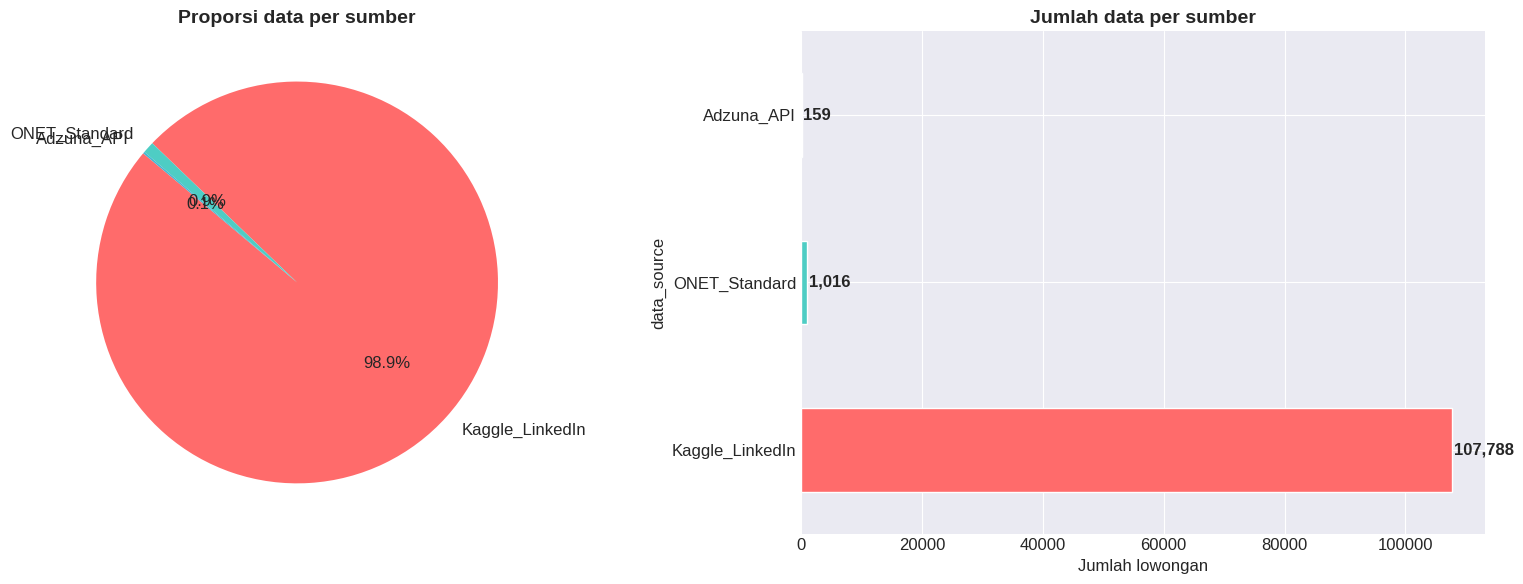

In [7]:
# ==============================================================================
# FUNGSI CELL: Memvisualisasikan perbandingan proporsi kontribusi data dari setiap 
# sumber data menggunakan Pie Chart (Proporsi) dan Bar Chart (Jumlah Data).
# ==============================================================================

# Membuat kanvas visualisasi berukuran 1 baris x 2 kolom dengan subplot
# Parameter pertama: Jumlah baris (nrows=1)
# Parameter kedua: Jumlah kolom subplot (ncols=2)
# Parameter figsize: Dimensi lebar dan tinggi kanvas dalam inci (16x6 inci)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Menghitung distribusi sumber data dari kolom data_source menggunakan value_counts()
source_counts = df["data_source"].value_counts()
colors = ["#FF6B6B", "#4ECDC4", "#45B7D1"]

# 1. Menggambar Pie Chart di kolom pertama (axes[0])
# Parameter pertama dari pie(): Array data frekuensi/nilai kontribusi
# Parameter labels: List label teks untuk setiap potongan kue
# Parameter autopct: Format persentase string yang dicetak ("%1.1f%%")
# Parameter colors: List warna untuk setiap potongan
# Parameter startangle: Sudut putaran awal gambar pie chart (140 derajat)
# Parameter textprops: Kamus properti teks (ukuran font 12)
axes[0].pie(
    source_counts.values,
    labels=source_counts.index,
    autopct="%1.1f%%",
    colors=colors,
    startangle=140,
    textprops={"fontsize": 12}
)
axes[0].set_title("Proporsi data per sumber", fontsize=14, fontweight="bold")

# 2. Menggambar Horizontal Bar Chart di kolom kedua (axes[1])
# Parameter kind: Jenis plot yang digambar ('barh' = bar chart horizontal)
# Parameter ax: Subplot tempat menggambar plot (axes[1] = kolom kedua)
# Parameter color: Warna batang grafik
# Parameter edgecolor: Warna garis tepi batang grafik ('white')
source_counts.plot(kind="barh", ax=axes[1], color=colors, edgecolor="white")
axes[1].set_xlabel("Jumlah lowongan")
axes[1].set_title("Jumlah data per sumber", fontsize=14, fontweight="bold")
# Menambahkan teks angka jumlah data pada setiap bar di grafik
for i, v in enumerate(source_counts.values):
  axes[1].text(v + 200, i, f"{v:,}", va="center", fontweight="bold")

# Mengatur tata letak grafik agar tidak saling bertumpuk
plt.tight_layout()
# Menyimpan gambar visualisasi ke file lokal
# Parameter pertama: Path/nama file tempat menyimpan gambar
# Parameter dpi: Resolusi kejelasan gambar dalam Dots Per Inch (150)
# Parameter bbox_inches: Memotong area spasi luar agar rapat ('tight')
plt.savefig("ada_sumber_data.png", dpi=150, bbox_inches="tight")
# Menampilkan visualisasi ke layar
plt.show()

logger.info("Distribusi sumber data: ")
for src, count in source_counts.items():
  logger.info(f" {src:20s}: {count:>8,} baris ({count/len(df)*100:.1f}%)")


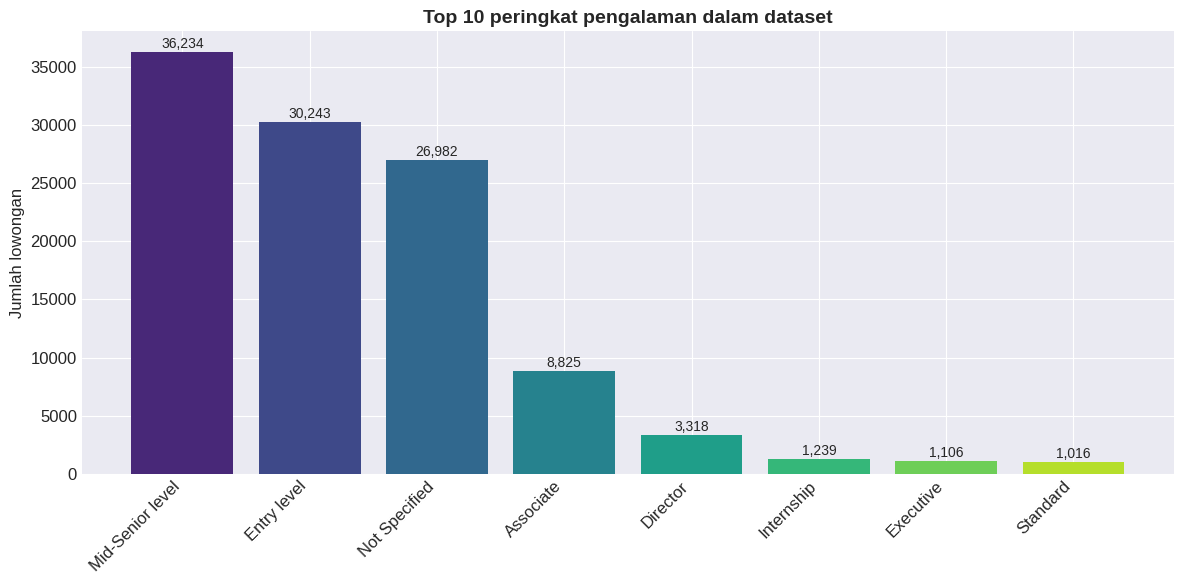

In [8]:
# ==============================================================================
# FUNGSI CELL: Menggambar visualisasi distribusi tingkat pengalaman kerja 
# (experience level) teratas yang paling dominan diminta dalam lowongan kerja.
# ==============================================================================

# Membuat kanvas gambar matplotlib
# Parameter figsize: Dimensi lebar dan tinggi kanvas dalam inci (12x6 inci)
fig, ax = plt.subplots(figsize=(12, 6))

# Menghitung 10 besar frekuensi data tingkat pengalaman dari experience_level
exp_counts = df["experience_level"].value_counts().head(10)
# Menggambar bar chart
# Parameter pertama: Range posisi index X
# Parameter kedua: Array data nilai tinggi bar (jumlah lowongan)
# Parameter color: Palet gradasi warna (di sini menggunakan viridis dengan jumlah kelas)
bars = ax.bar(range(len(exp_counts)), exp_counts.values, color=sns.color_palette("viridis", len(exp_counts)))
# Mengatur ticks sumbu X berdasarkan posisi data
ax.set_xticks(range(len(exp_counts)))
# Menambahkan label tingkat pengalaman pada sumbu X dengan rotasi 45 derajat
# Parameter pertama: Daftar label teks sumbu X
# Parameter rotation: Sudut kemiringan rotasi teks (45 derajat)
# Parameter ha: Penyelarasan horizontal teks ('right')
ax.set_xticklabels(exp_counts.index, rotation=45, ha="right")
ax.set_ylabel("Jumlah lowongan")
ax.set_title("Top 10 peringkat pengalaman dalam dataset", fontsize=14, fontweight="bold")

# Menambahkan teks angka di atas setiap bar grafik
for bar, val in zip(bars, exp_counts.values):
  ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
          f"{val:,}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
# Menyimpan gambar grafik
plt.savefig("edo_experience_level.png", dpi=150, bbox_inches="tight")
plt.show()


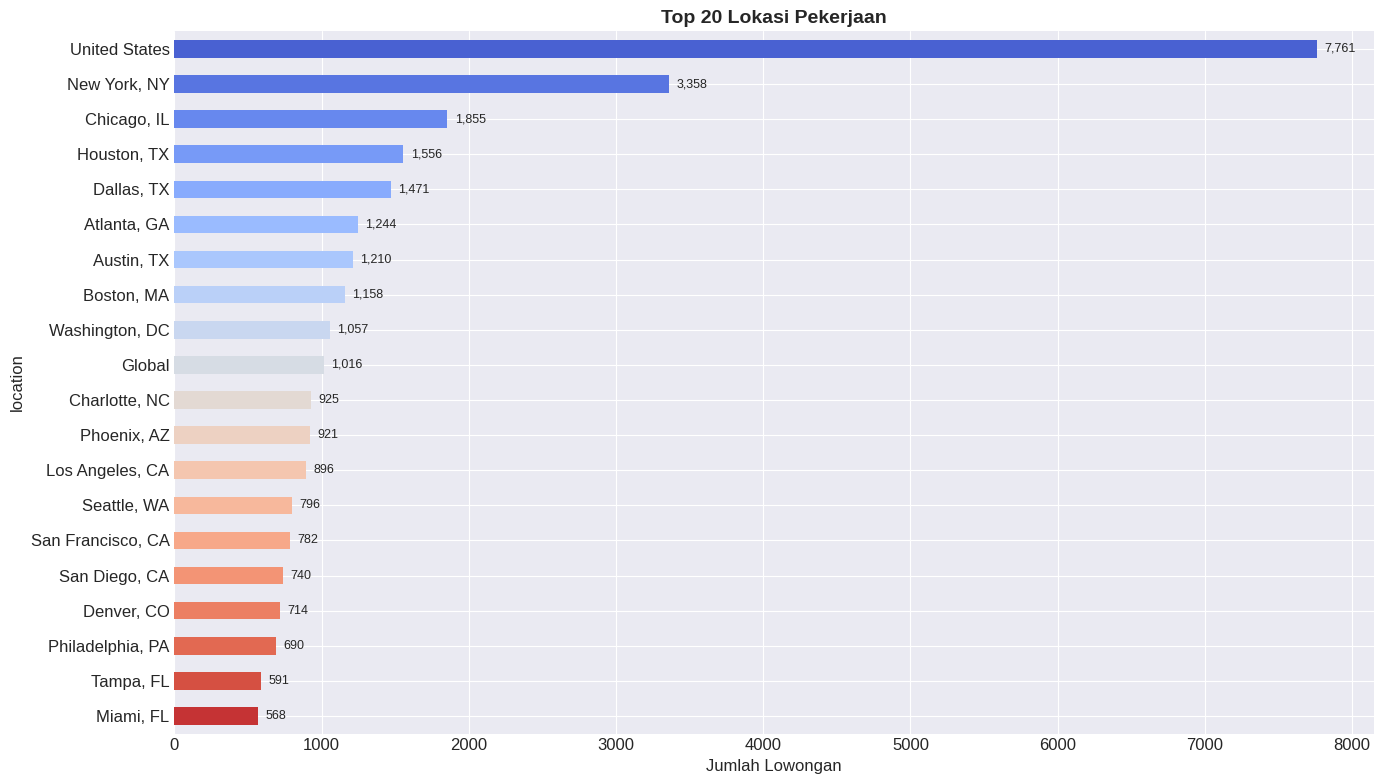

In [9]:
# ==============================================================================
# FUNGSI CELL: Menggambar grafik batang horizontal yang menampilkan 20 lokasi 
# pekerjaan dengan jumlah lowongan terbanyak dalam dataset.
# ==============================================================================

# Membuat kanvas visualisasi 14x8 inci
fig, ax = plt.subplots(figsize=(14, 8))

# Menghitung 20 teratas frekuensi data lokasi pekerjaan
loc_counts = df["location"].value_counts().head(20)
# Menggambar Bar Chart Horizontal menggunakan plot()
# Parameter kind: Jenis plot ('barh' = horizontal bar)
# Parameter ax: Kanvas grafik tujuan
# Parameter color: Palet warna ('coolwarm' dengan jumlah kelas 20)
loc_counts.plot(kind="barh", ax=ax, color=sns.color_palette("coolwarm", 20))
ax.set_xlabel("Jumlah Lowongan")
ax.set_title("Top 20 Lokasi Pekerjaan", fontsize=14, fontweight="bold")
# Membalik sumbu Y agar lokasi dengan jumlah terbanyak tampil di posisi atas
ax.invert_yaxis()

# Menambahkan teks label angka di samping kanan setiap batang grafik
for i, v in enumerate(loc_counts.values):
    ax.text(v + 50, i, f"{v:,}", va="center", fontsize=9)

plt.tight_layout()
# Menyimpan gambar grafik
plt.savefig("eda_lokasi.png", dpi=150, bbox_inches="tight")
plt.show()


(array([4.400e+02, 3.200e+01, 2.300e+01, 1.790e+02, 6.610e+02, 1.128e+03,
        1.529e+03, 1.766e+03, 1.565e+03, 1.477e+03, 1.362e+03, 1.219e+03,
        1.100e+03, 9.800e+02, 8.340e+02, 6.340e+02, 6.220e+02, 5.130e+02,
        3.950e+02, 3.430e+02, 2.230e+02, 2.020e+02, 1.790e+02, 1.310e+02,
        9.800e+01, 8.400e+01, 7.200e+01, 6.500e+01, 5.100e+01, 4.900e+01,
        2.000e+01, 2.800e+01, 1.300e+01, 1.600e+01, 2.200e+01, 4.000e+00,
        4.000e+00, 8.000e+00, 1.000e+01, 1.000e+01, 8.000e+00, 5.000e+00,
        9.000e+00, 6.000e+00, 1.100e+01, 3.000e+00, 1.000e+00, 5.000e+00,
        2.000e+00, 5.000e+00]),
 array([  1050.,  11029.,  21008.,  30987.,  40966.,  50945.,  60924.,
         70903.,  80882.,  90861., 100840., 110819., 120798., 130777.,
        140756., 150735., 160714., 170693., 180672., 190651., 200630.,
        210609., 220588., 230567., 240546., 250525., 260504., 270483.,
        280462., 290441., 300420., 310399., 320378., 330357., 340336.,
        350315., 3602

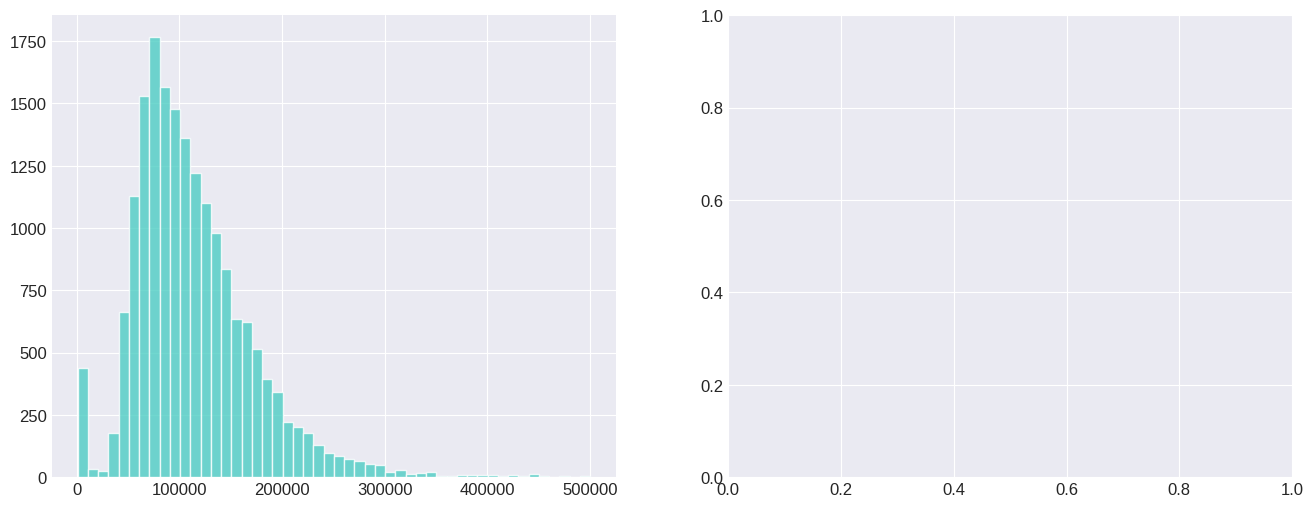

In [10]:
# ==============================================================================
# FUNGSI CELL: Menganalisis sebaran gaji lowongan kerja, membuang data outlier 
# (gaji < $1k atau > $500k), lalu menggambarkan histogram distribusi gaji.
# ==============================================================================

# Menyaring data lowongan yang memiliki informasi gaji (tidak null di kolom min_salary & max_salary)
# Parameter subset: List kolom acuan yang diperiksa nilai kosongnya (dropna menghapus baris jika null)
df_salary = df.dropna(subset=["min_salary", "max_salary"]).copy()
# Menghitung rata-rata gaji dari min_salary dan max_salary
df_salary["avg_salary"] = (df_salary["min_salary"] + df_salary["max_salary"]) / 2

# Menyaring outlier data gaji yang kurang realistis (di luar rentang $1k sampai $500k)
df_salary = df_salary[
    (df_salary["avg_salary"] >= 1000) & (df_salary["avg_salary"] <= 500000)
]

logger.info(f"Data dengan data info gaji valid: {len(df_salary):,} baris "
            f"({len(df_salary)/len(df)*100:.1f}% dari total)")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram sebaran rata-rata gaji
# Parameter pertama: Array data numerik (avg_salary) yang akan digambar sebarannya
# Parameter bins: Jumlah kotak/interval pembagi data (50 bins)
# Parameter color: Warna batang histogram
# Parameter edgecolor: Warna garis tepi kotak
# Parameter alpha: Nilai transparansi grafik (0.8)
axes[0].hist(df_salary["avg_salary"], bins=50, color="#4ECDC4", edgecolor="white", alpha=0.8)
axes[0].set_xlabel("Rata-rata Gaji ($)")
axes[0].set_ylabel("Jumlah Lowongan")
axes[0].set_title("Distribusi Rata-rata Gaji Lowongan Kerja", fontsize=14, fontweight="bold")

# Box plot sebaran gaji per data_source
# Parameter data: DataFrame pandas sumber data
# Parameter x: Kolom sumbu X (kategori 'data_source')
# Parameter y: Kolom sumbu Y (numerik 'avg_salary')
# Parameter ax: Kanvas subplot tujuan
# Parameter palette: Skema kombinasi warna box plot ('husl')
sns.boxplot(data=df_salary, x="data_source", y="avg_salary", ax=axes[1], palette="husl")
axes[1].set_xlabel("Sumber Data")
axes[1].set_ylabel("Rata-rata Gaji ($)")
axes[1].set_title("Sebaran Gaji berdasarkan Sumber Data", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("eda_salary.png", dpi=150, bbox_inches="tight")
plt.show()


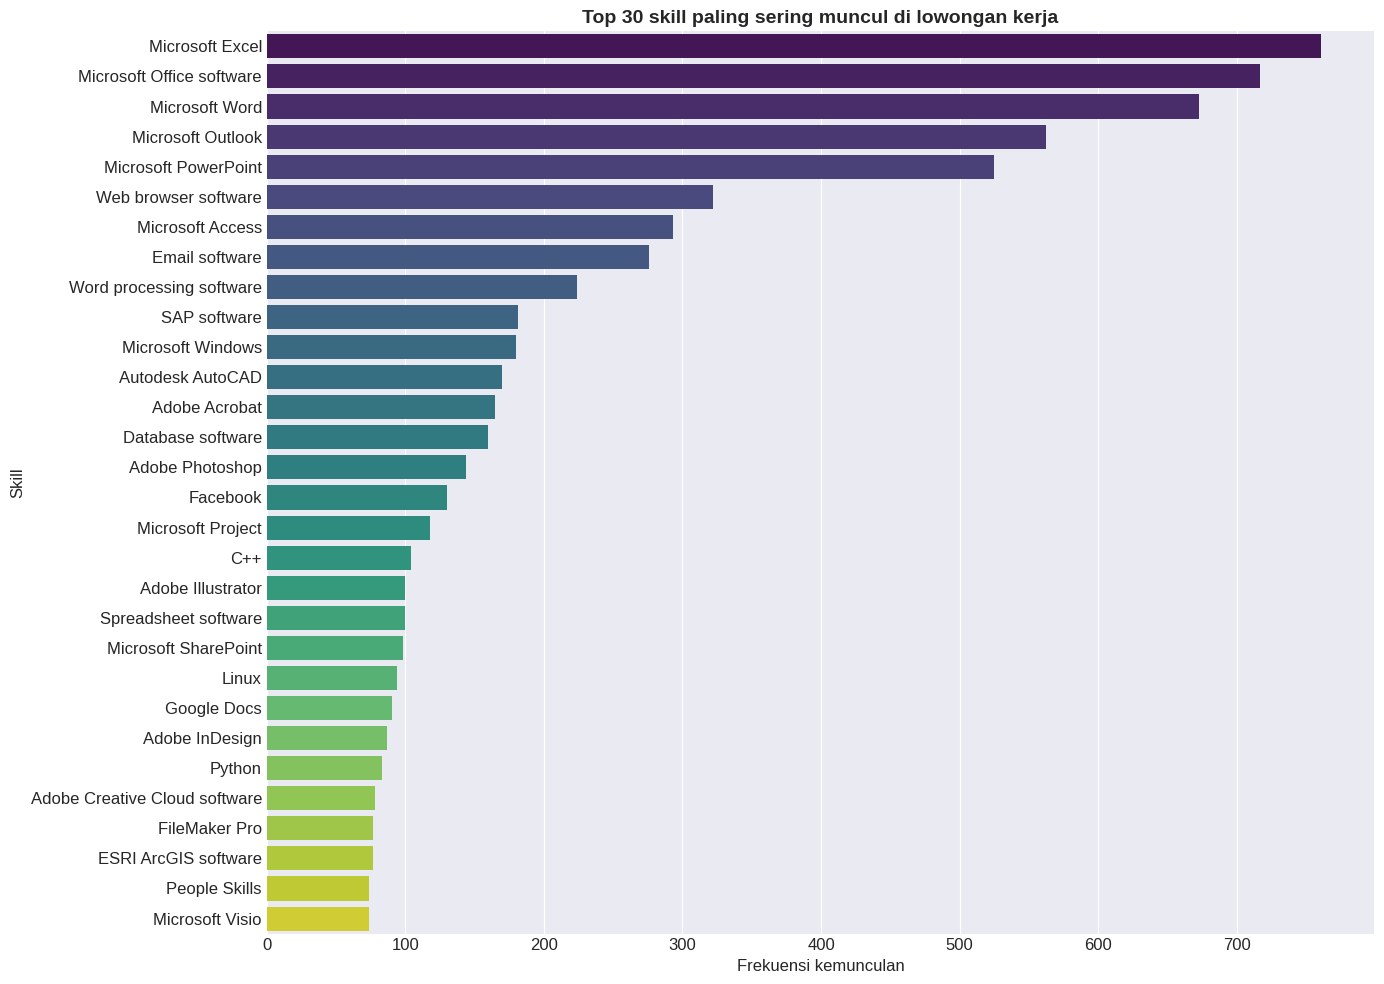

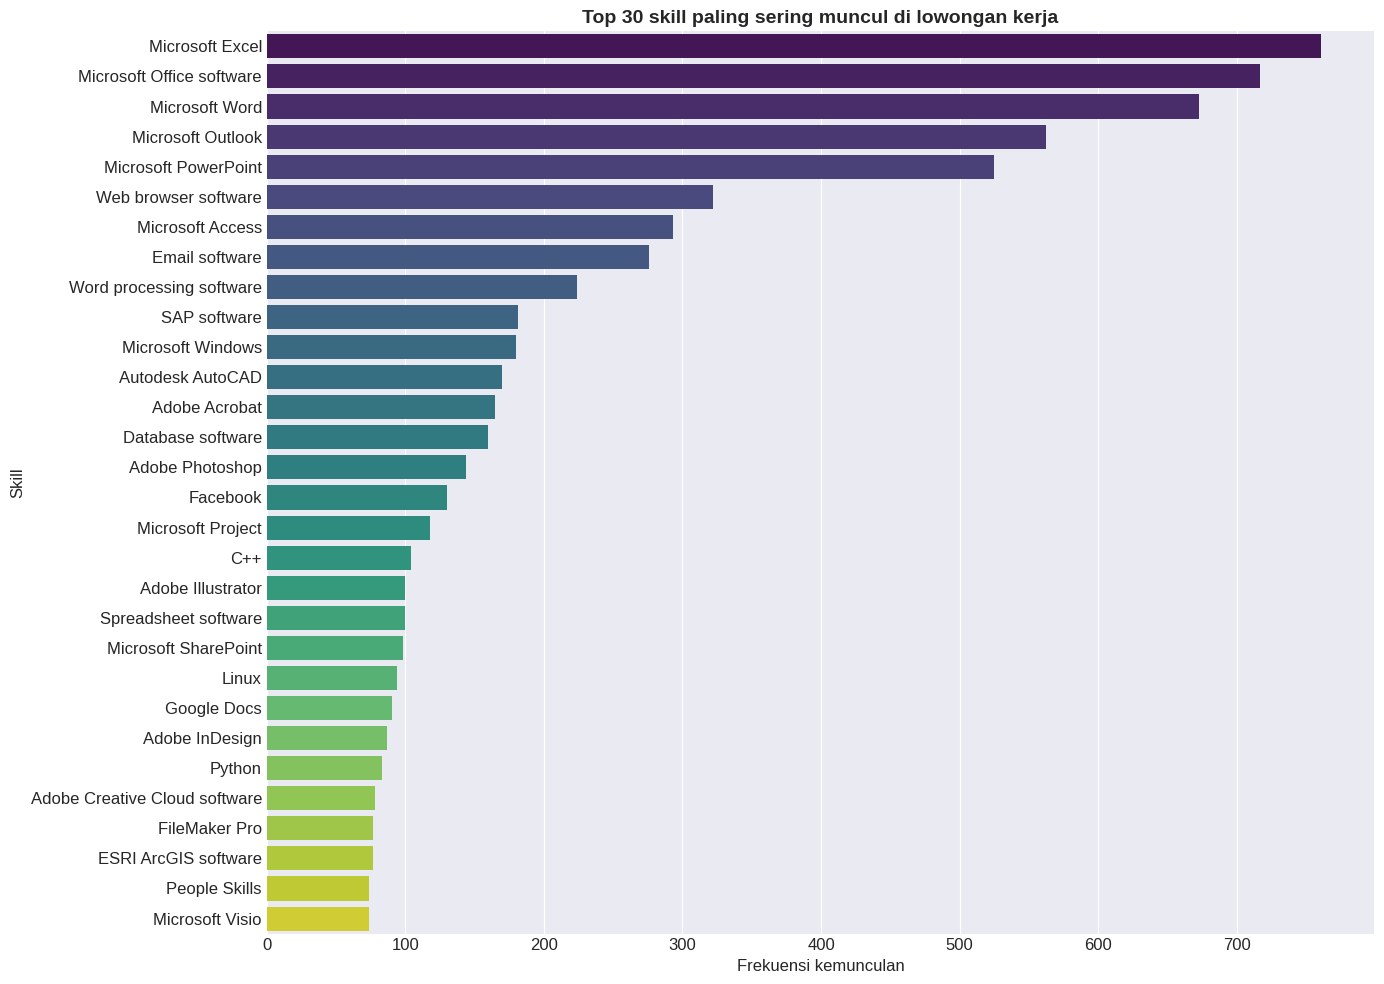

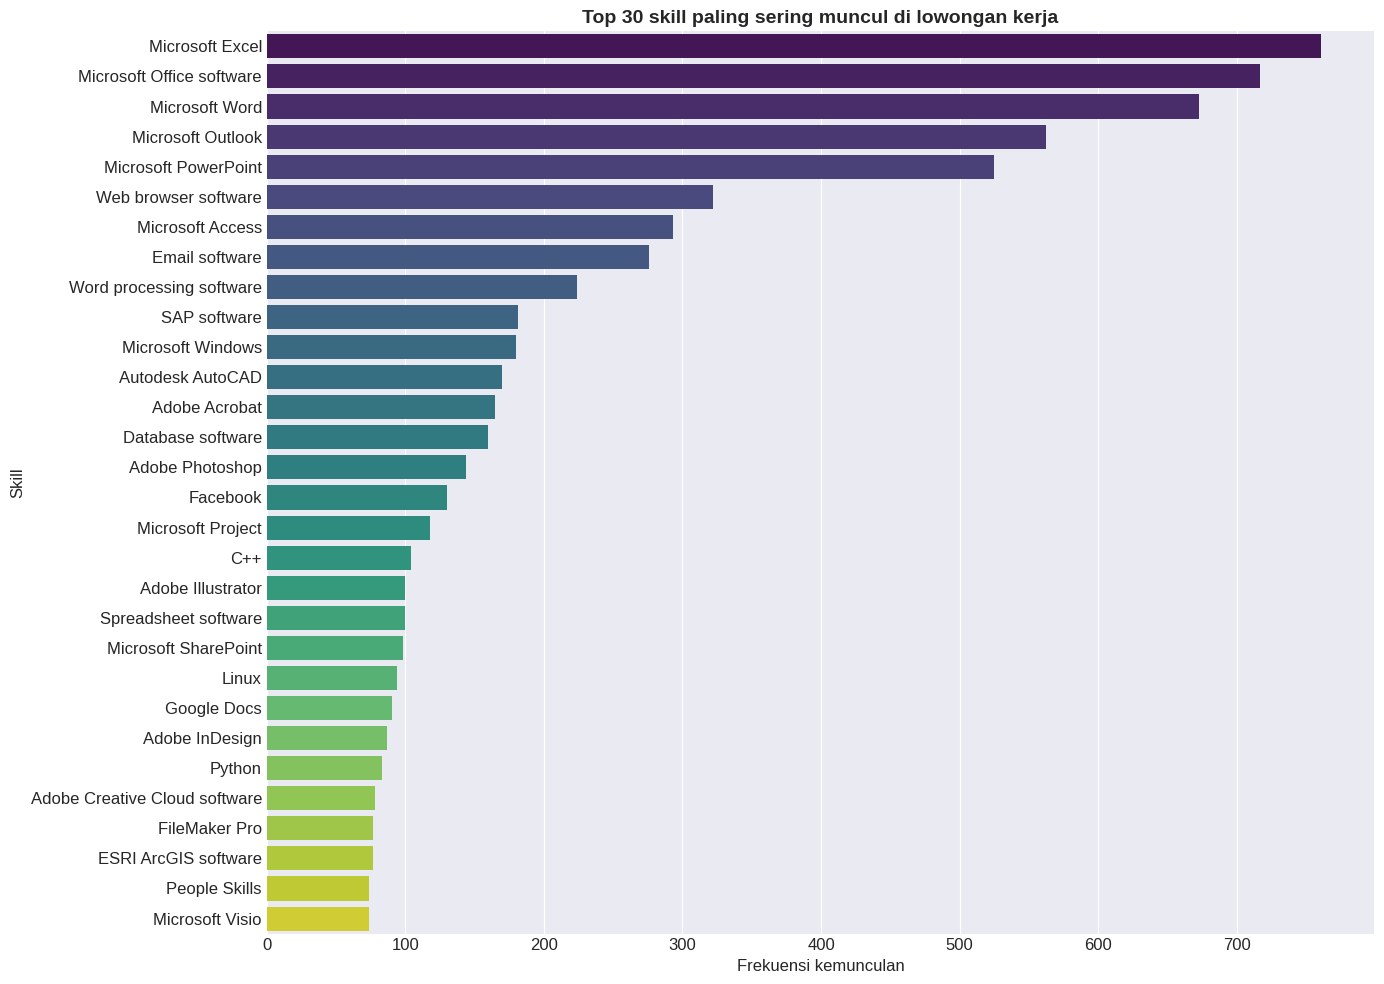

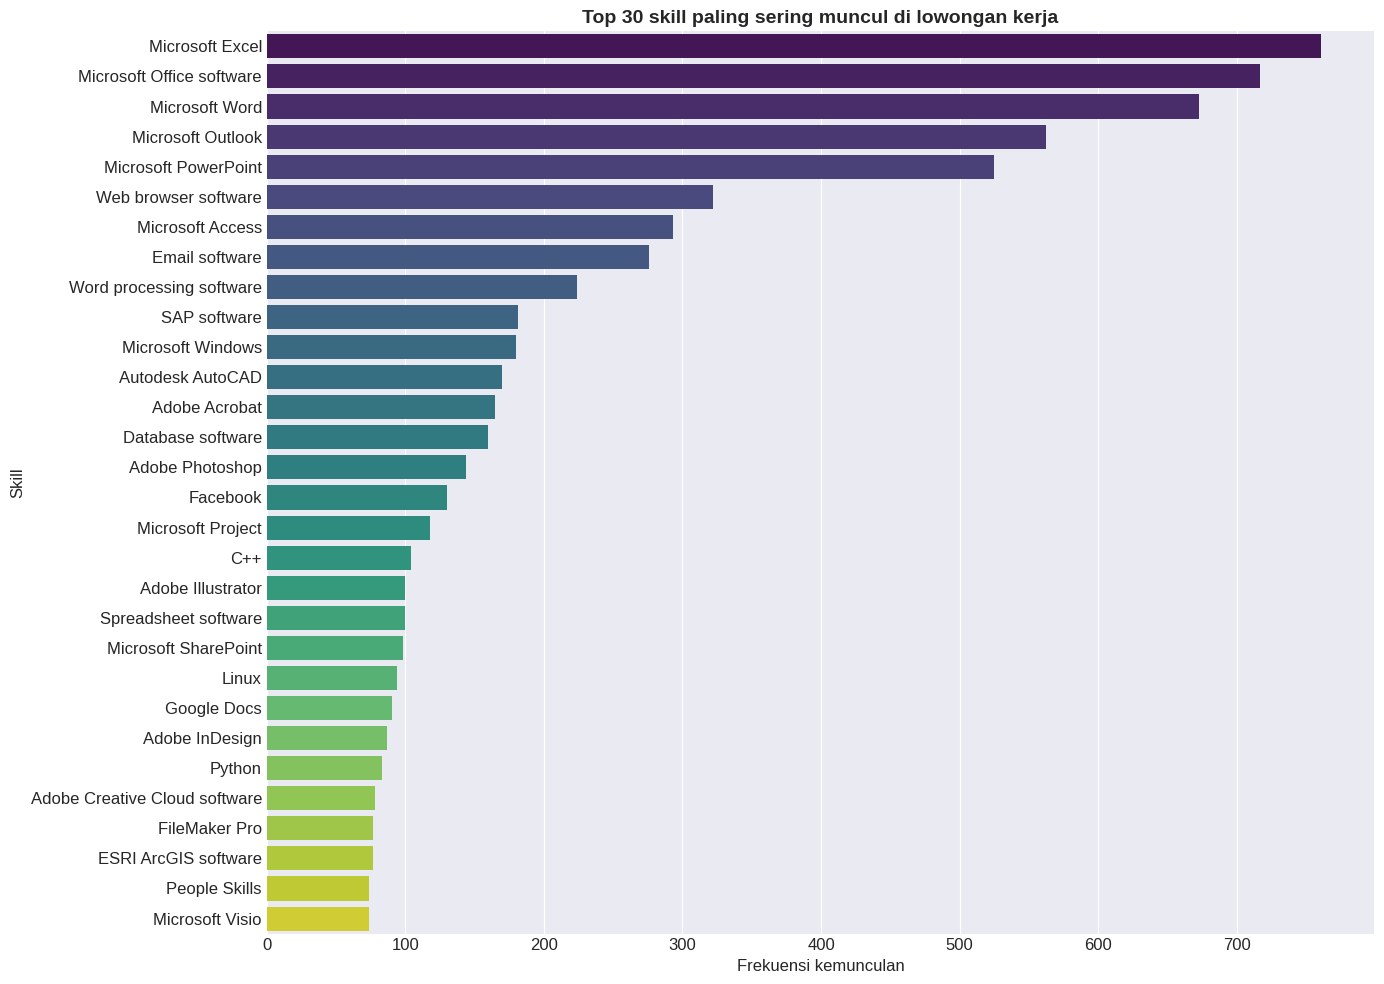

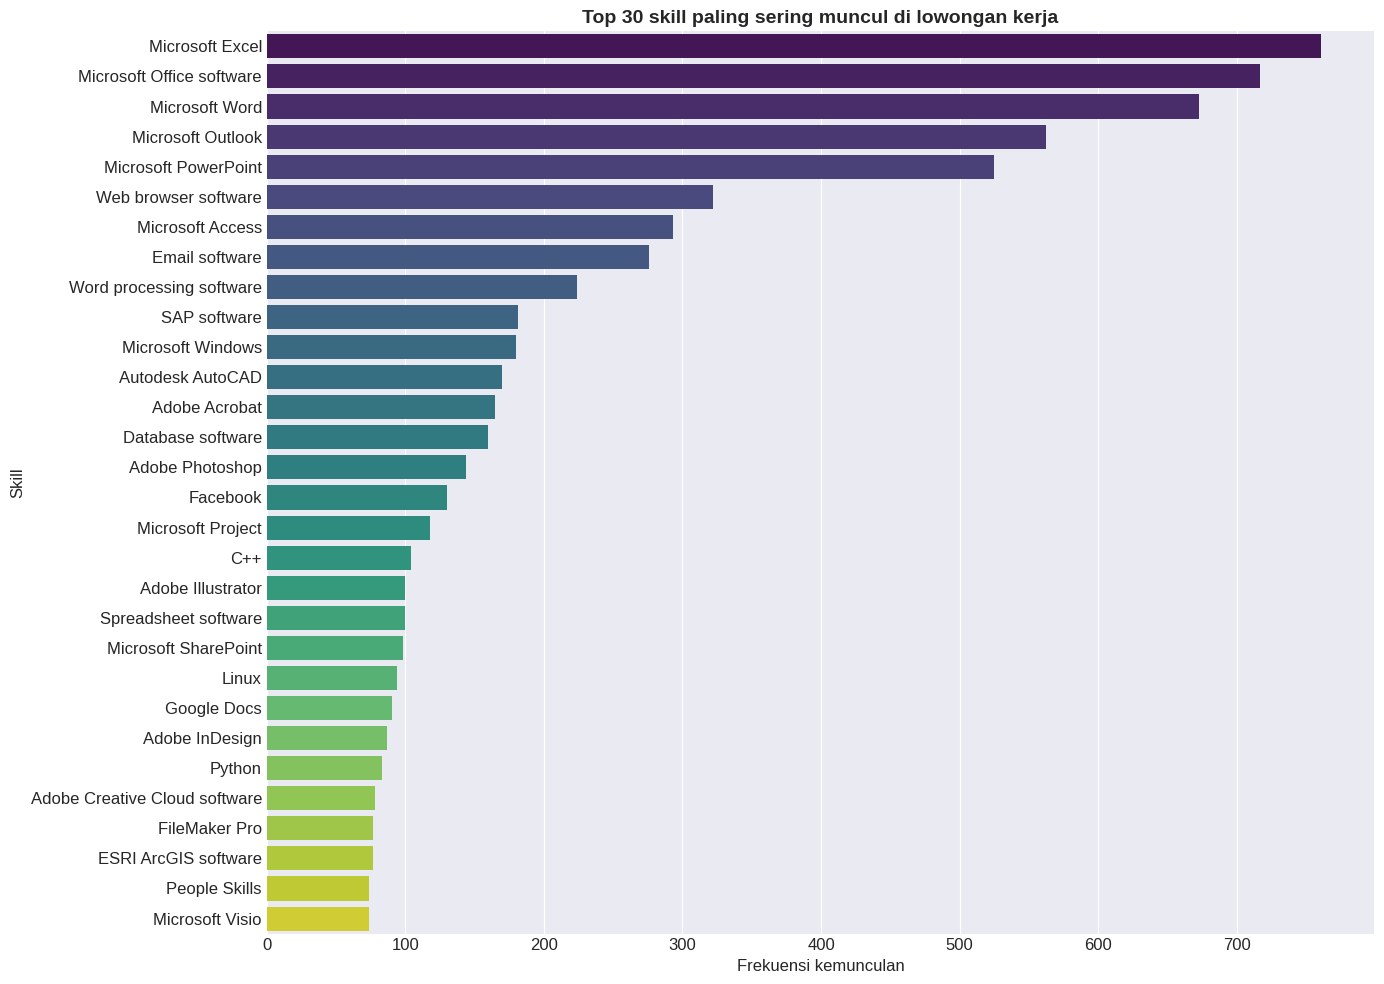

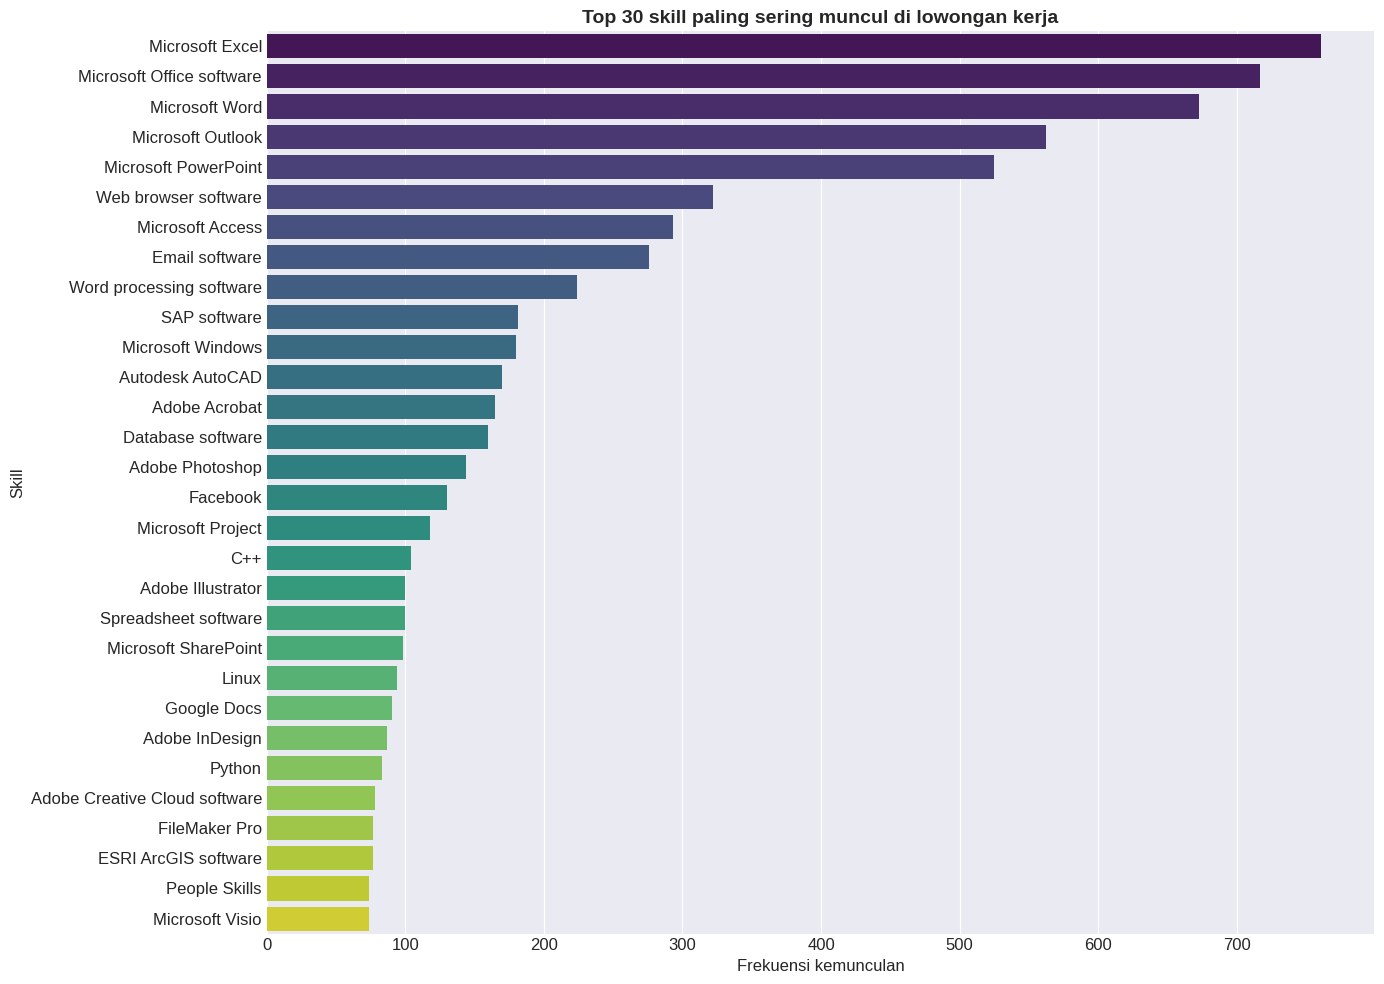

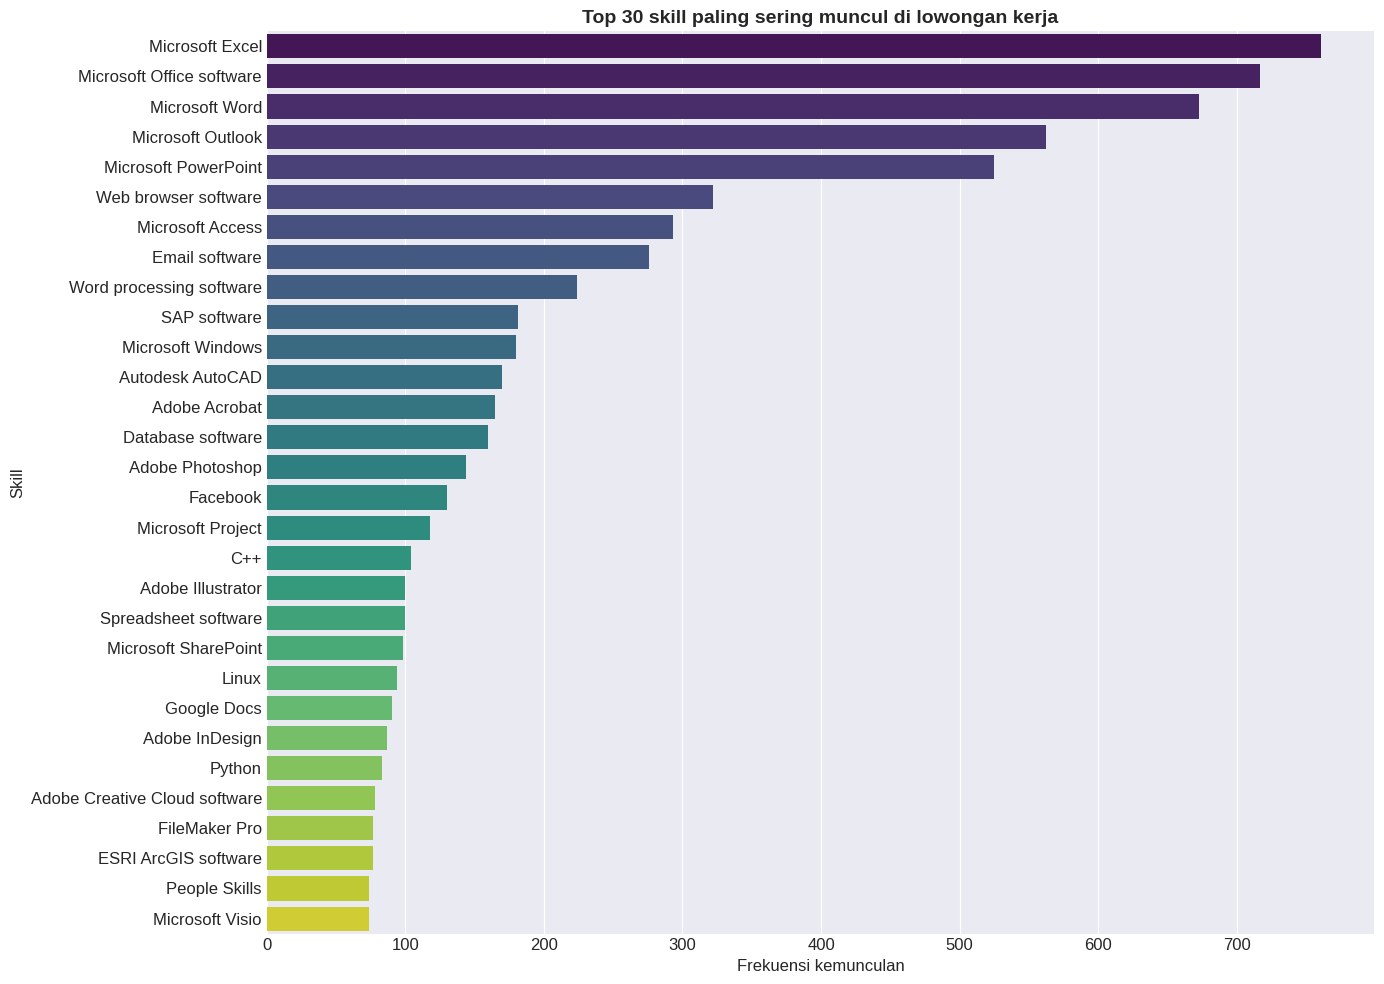

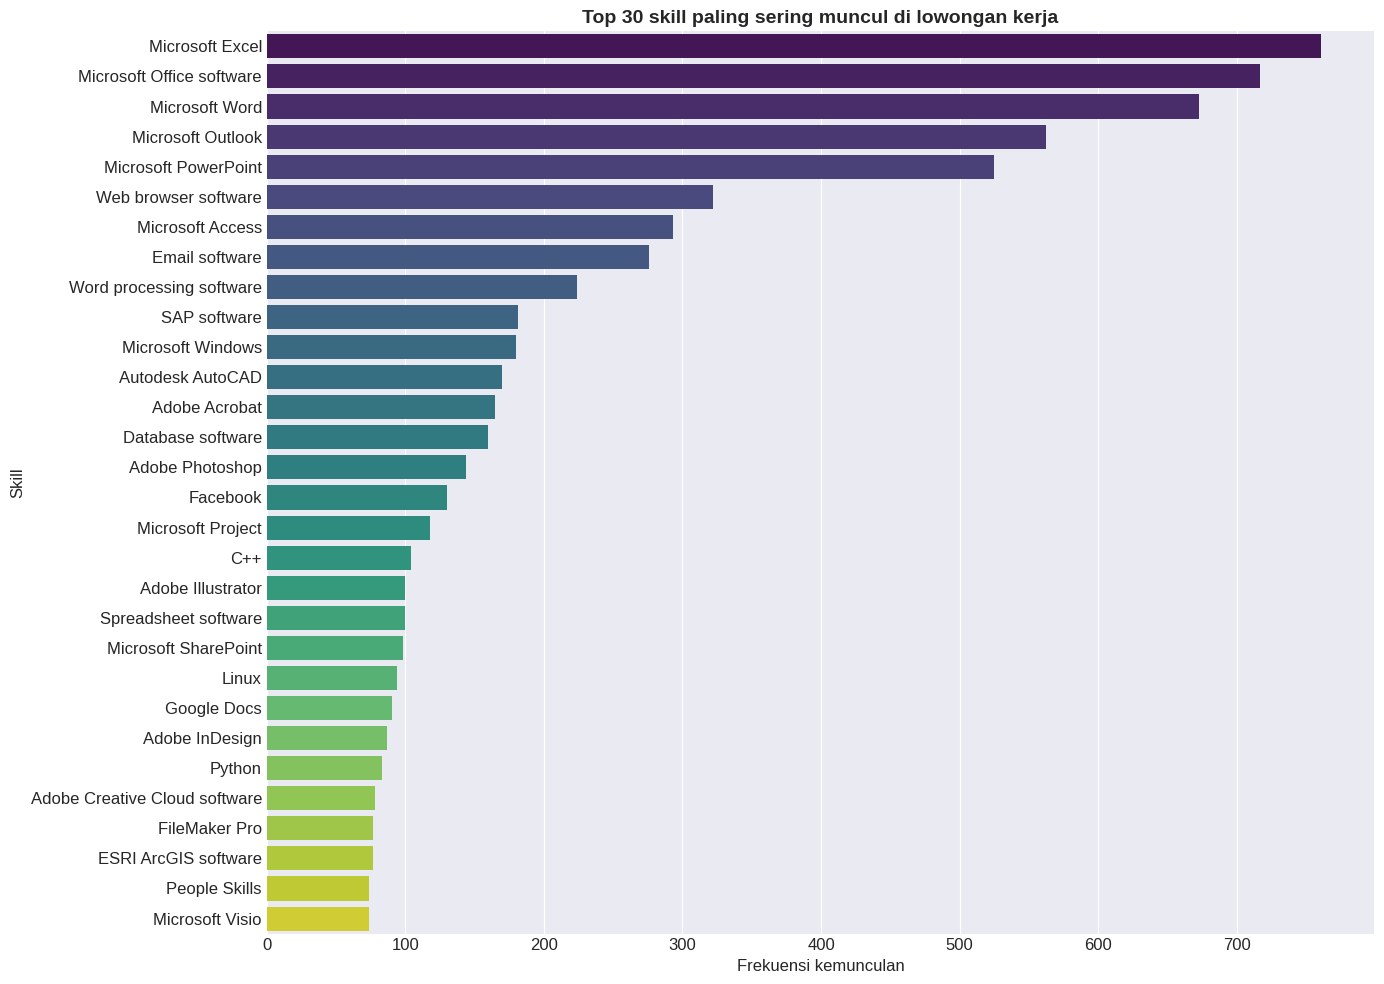

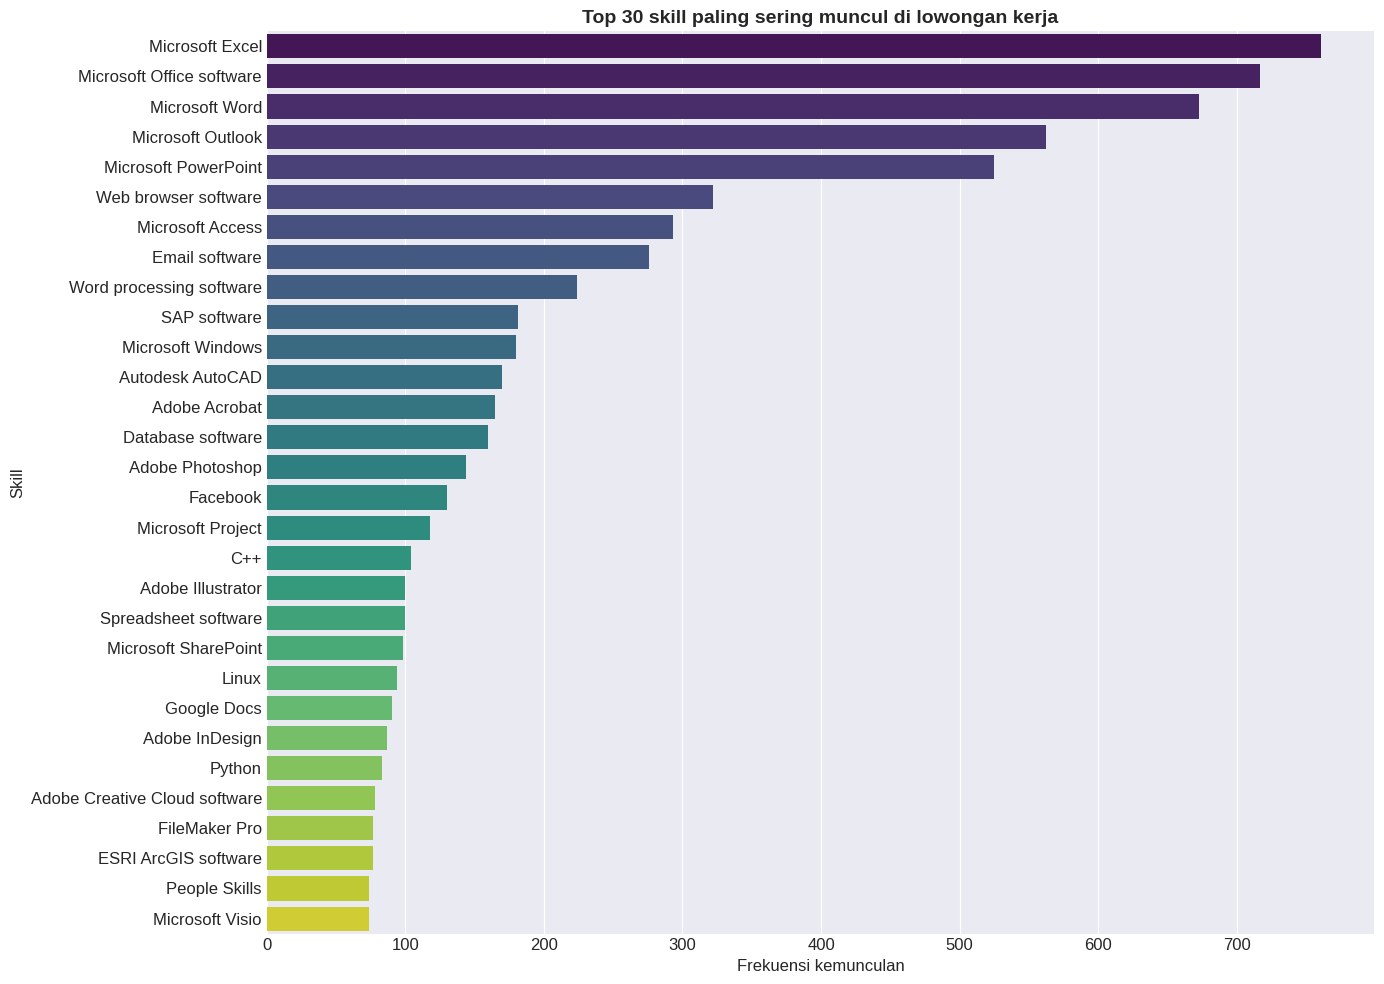

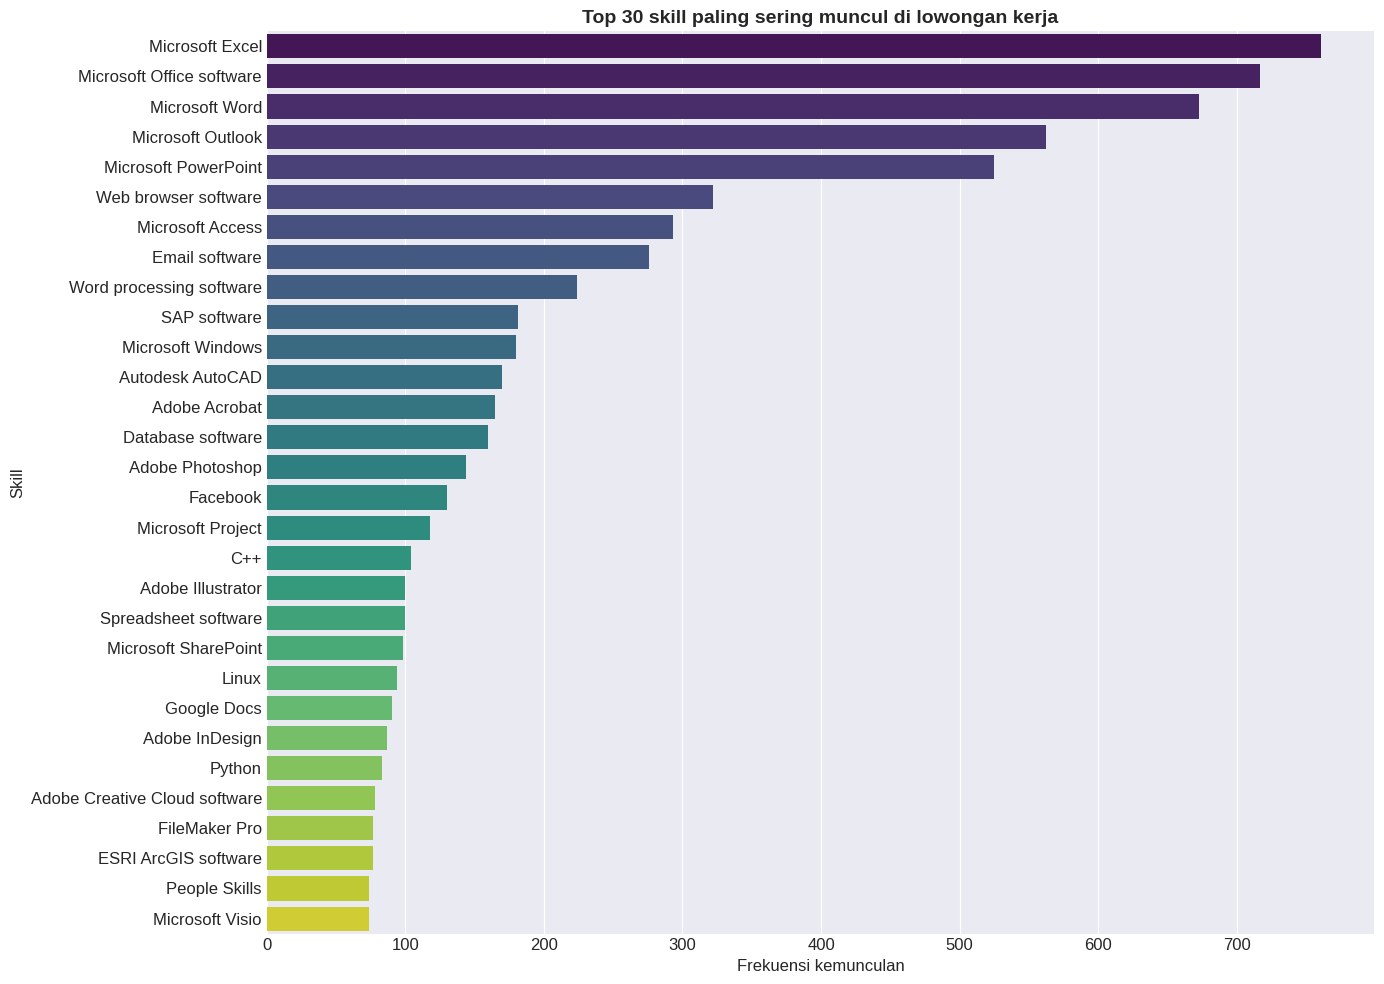

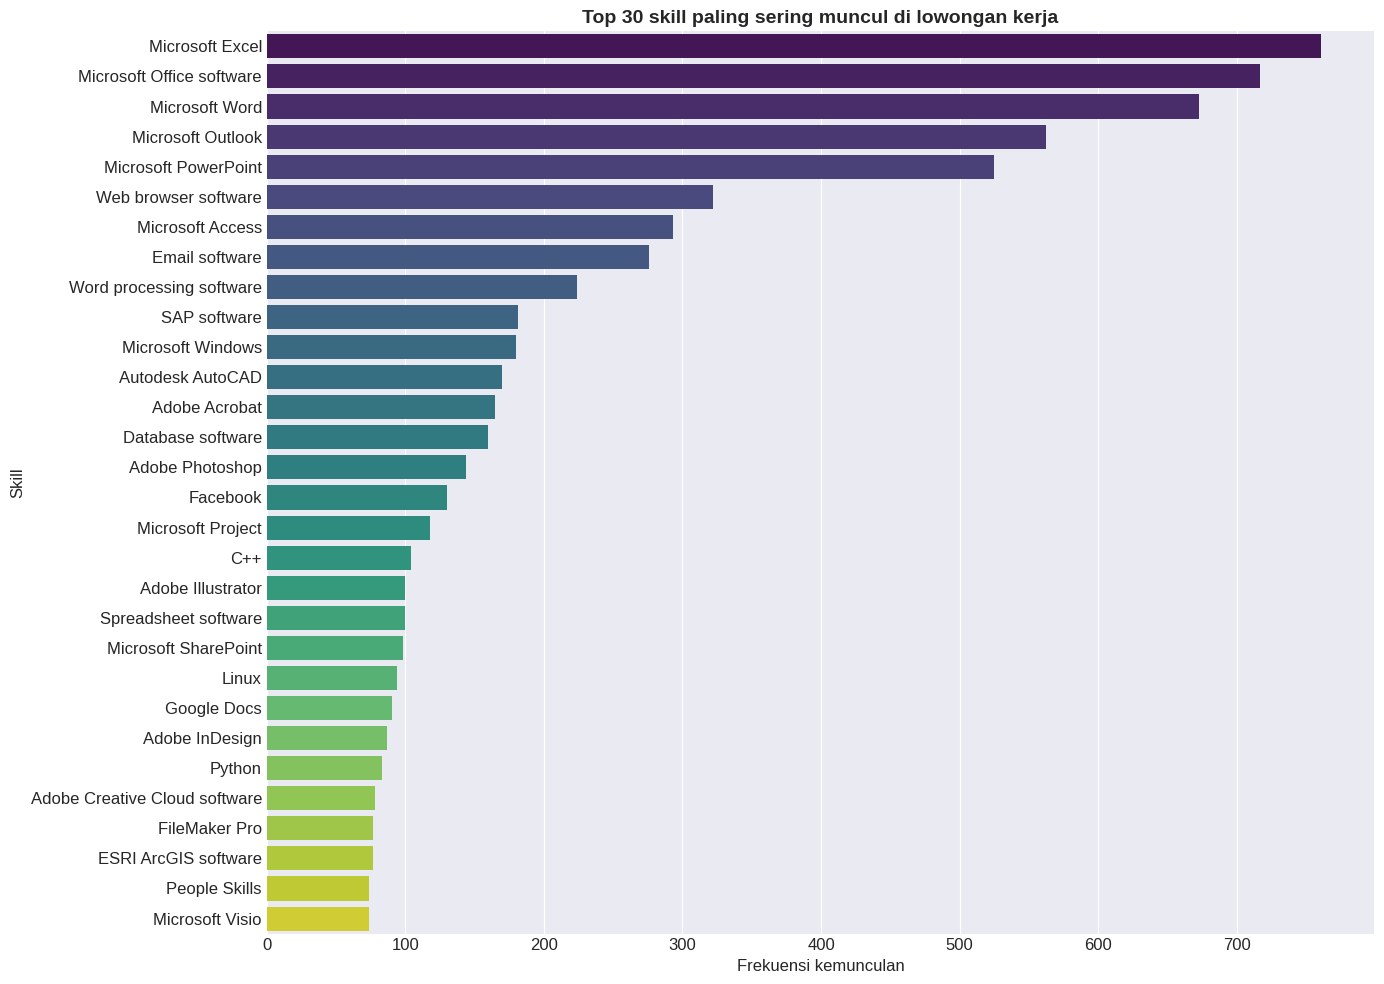

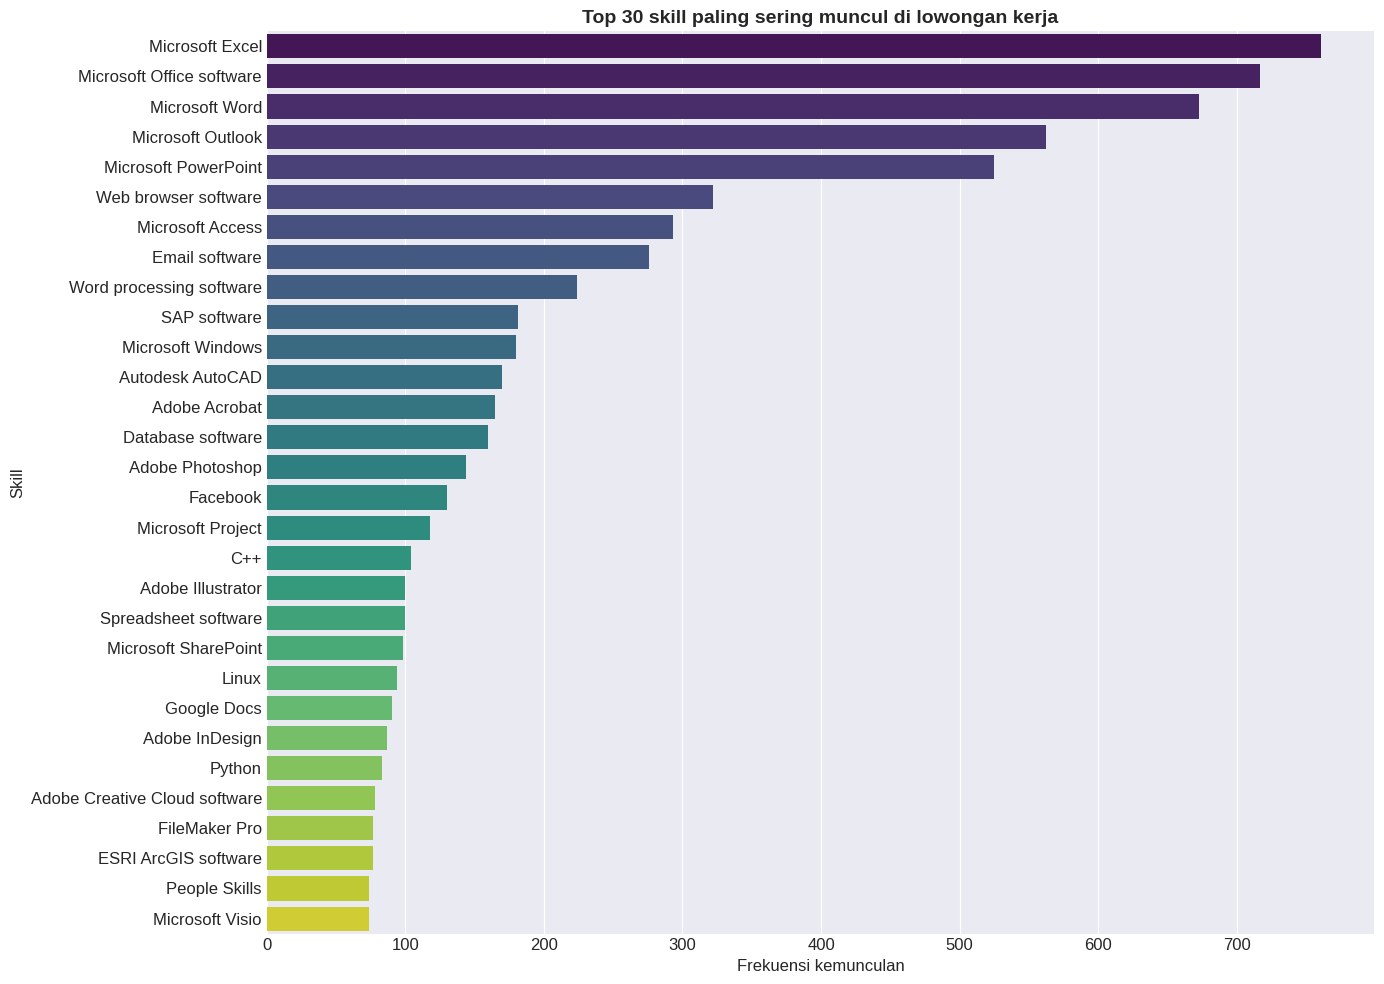

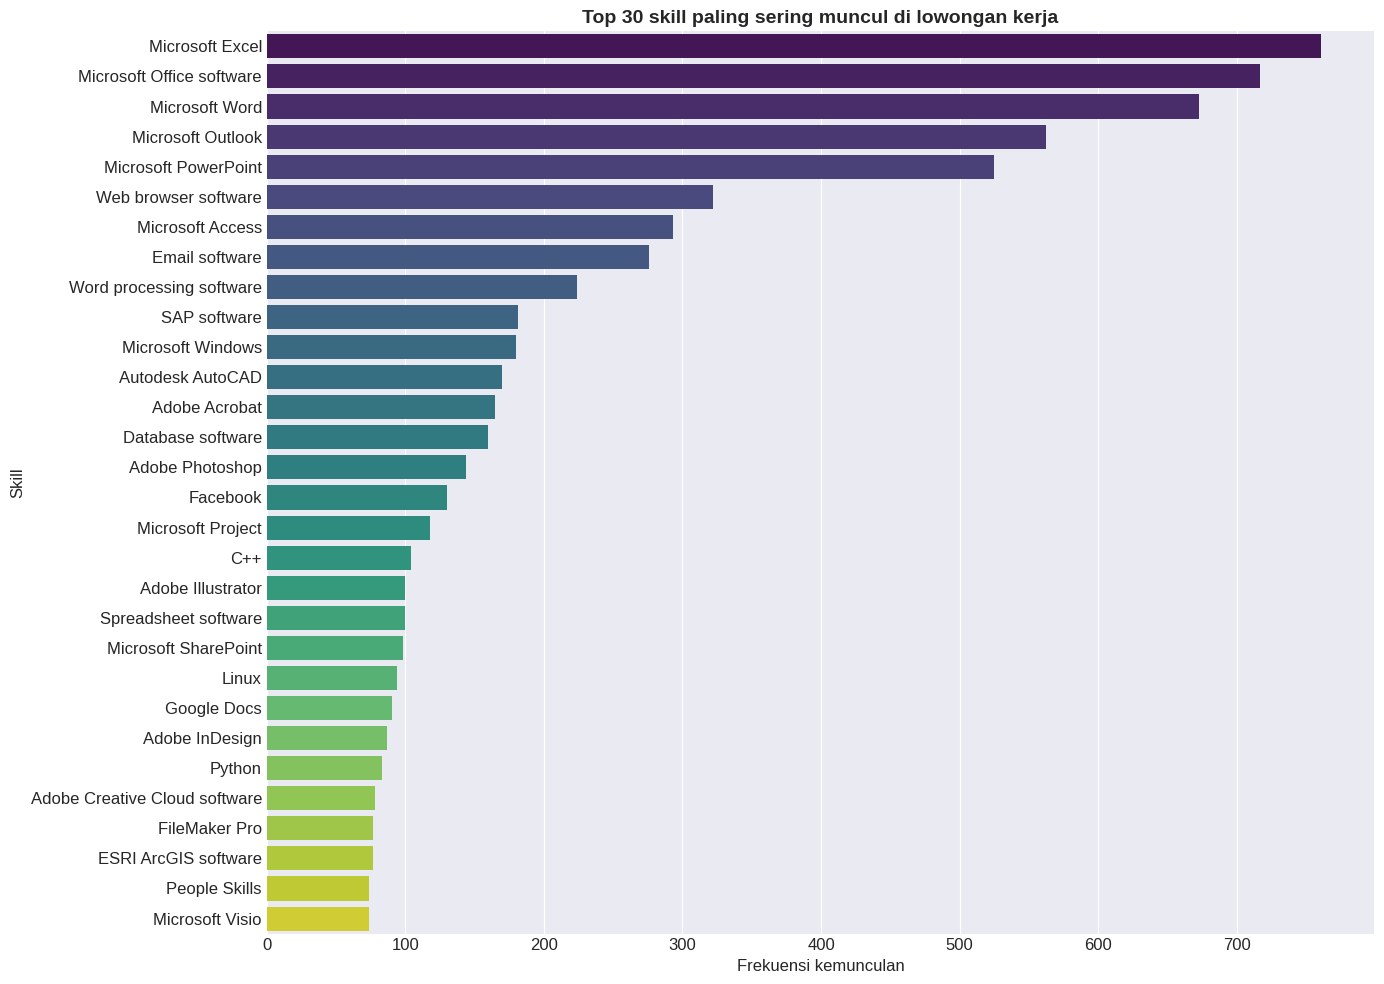

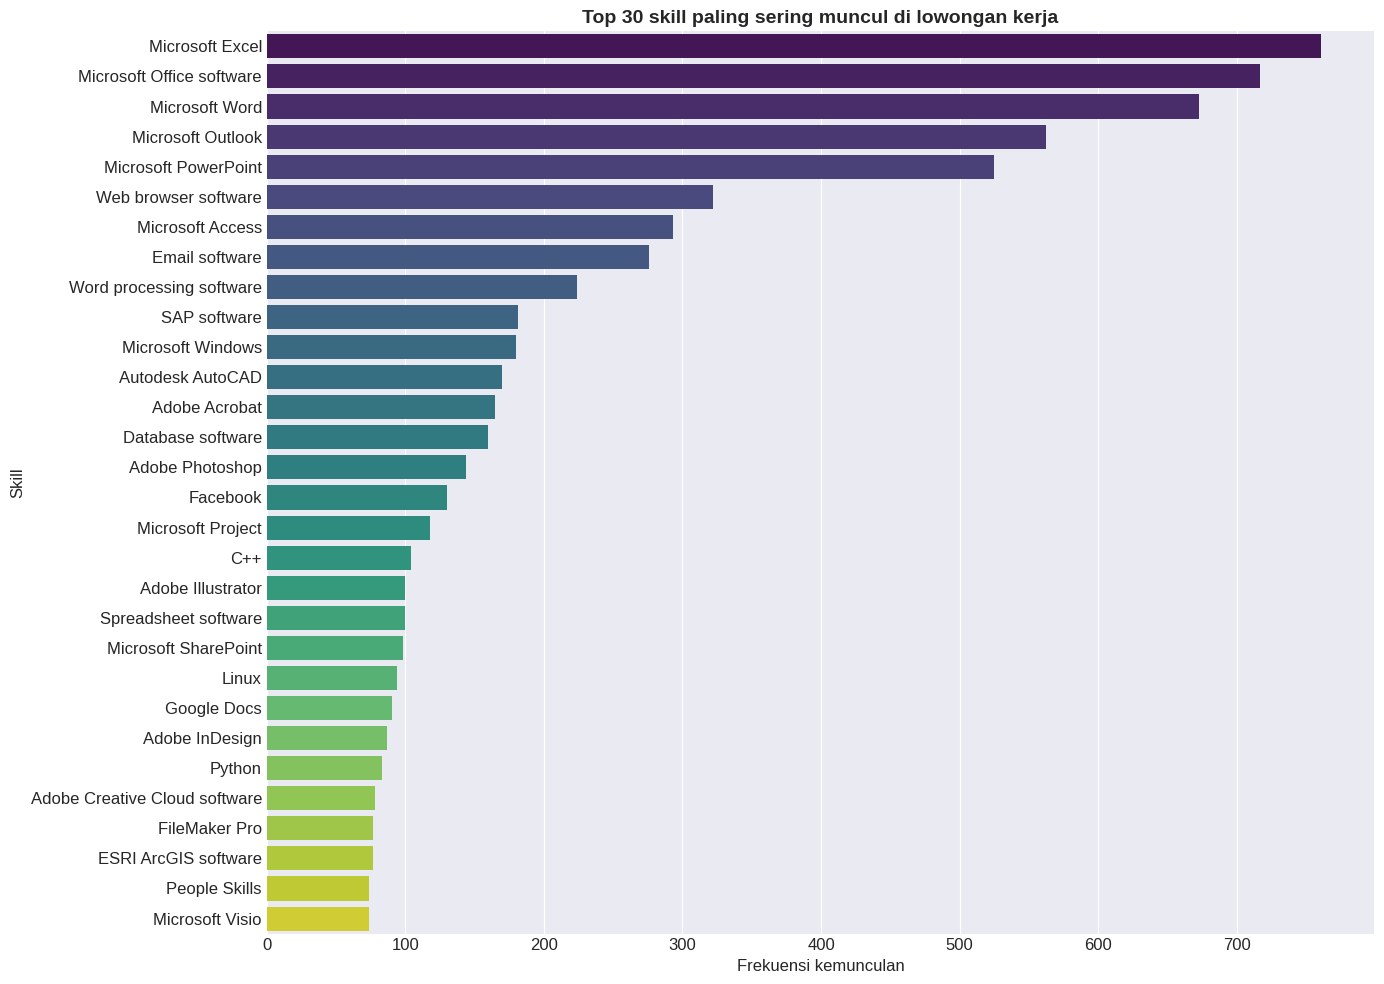

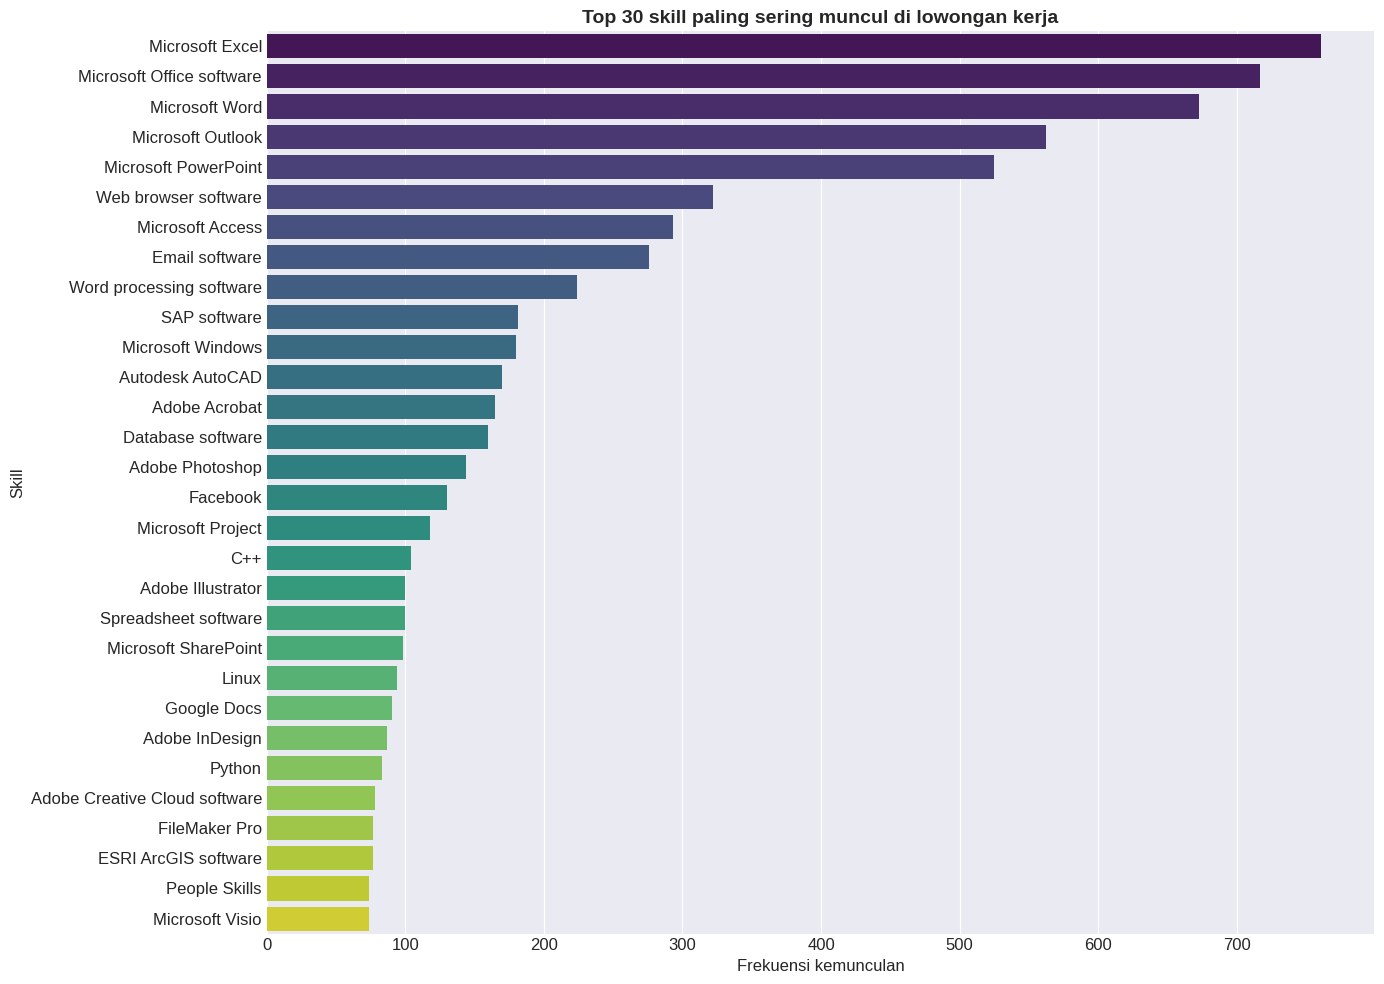

In [11]:
# ==============================================================================
# FUNGSI CELL: Mengekstrak, menghitung frekuensi, dan memvisualisasikan 30 skill 
# yang paling sering muncul/diwajibkan oleh perusahaan dalam dataset lowongan kerja.
# ==============================================================================

# Mendefinisikan fungsi pengekstraksi frekuensi skill
# Parameter df: DataFrame data lowongan
# Parameter column: Nama kolom target tempat mengekstrak daftar skill
def extract_skill_frequencies(df: pd.DataFrame, column: str = "skills_required") -> Counter:
  skill_counter = Counter()
  # Mengambil seri data kolom skill dan membuang nilai kosong
  skills_series = df[column].dropna()

  # Melakukan perulangan di setiap baris teks daftar skill
  for skills_text in skills_series:
    # Memisahkan nama skill dengan pembatas koma, menghapus spasi liar, dan membuang teks < 2 karakter
    skills = [s.strip() for s in str(skills_text).split(",") if len(s.strip()) > 1]
    # Meng-update objek counter dengan daftar skill dari baris ini
    skill_counter.update(skills)

  return skill_counter

# Menghitung frekuensi kemunculan skill
skill_freq = extract_skill_frequencies(df)
# Mengambil 30 besar skill yang paling sering muncul menggunakan most_common()
# Parameter pertama dari most_common: Jumlah item teratas yang akan diambil (30 item)
top_30_skills = skill_freq.most_common(30)

logger.info(f"Total skill unik ditemukan: {len(skill_freq):,}")
logger.info(f"\nTop 15 skill paling sering muncul:")
for skill, count in top_30_skills[:15]:
  logger.info(f" {skill:40s} -> {count:>6,} kali")

# Visualisasi 30 skill terpopuler
fig, ax = plt.subplots(figsize=(14, 10))
# Mengonversi 30 skill teratas ke DataFrame pandas
# Parameter columns: List nama kolom untuk DataFrame baru
skills_df = pd.DataFrame(top_30_skills, columns=["Skill", "Frekuensi"])
# Menggambar bar plot horizontal menggunakan seaborn.barplot
# Parameter data: DataFrame pandas sumber data
# Parameter y: Nama kolom data untuk sumbu Y (kategori 'Skill')
# Parameter x: Nama kolom data untuk sumbu X (nilai numerik 'Frekuensi')
# Parameter ax: Kanvas grafik tujuan
# Parameter palette: Palet warna grafik ('viridis')
sns.barplot(data=skills_df, y="Skill", x="Frekuensi", ax=ax, palette="viridis")
ax.set_title("Top 30 skill paling sering muncul di lowongan kerja", fontsize=14, fontweight="bold")
ax.set_xlabel("Frekuensi kemunculan")

plt.tight_layout()
# Menyimpan gambar grafik
plt.savefig("eda_skill_freq.png", dpi=150, bbox_inches="tight")
plt.show()


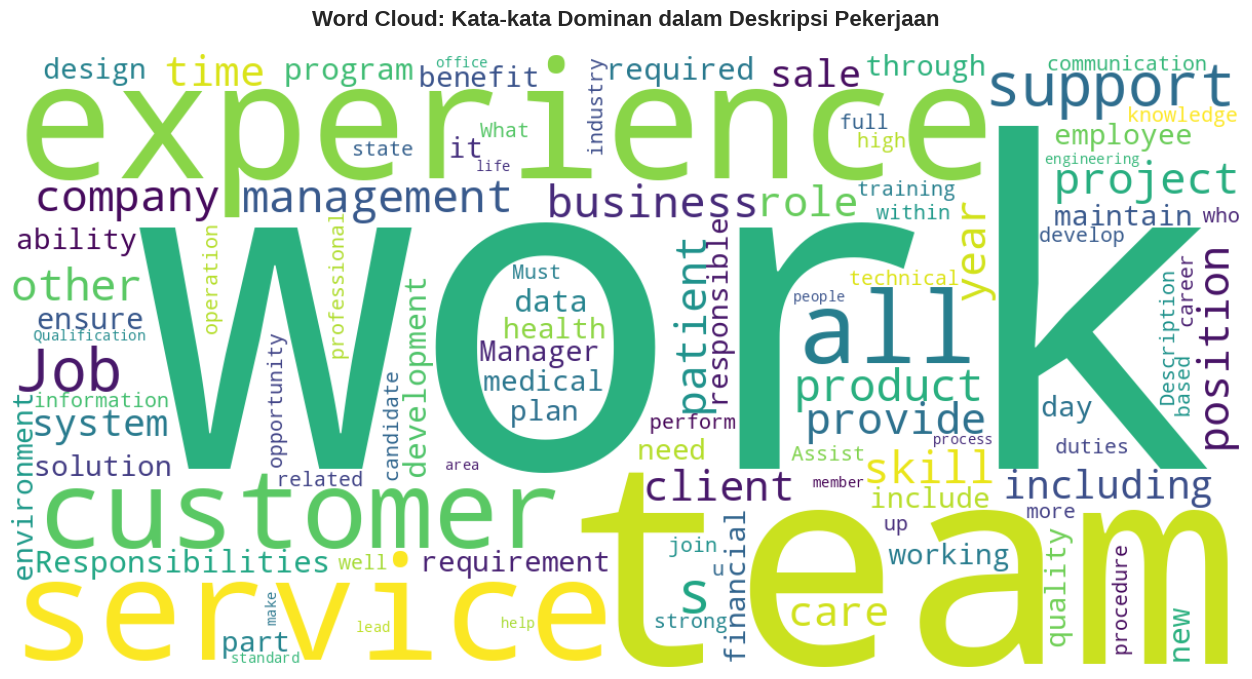

In [12]:
# ==============================================================================
# FUNGSI CELL: Membuat visualisasi Word Cloud dari teks deskripsi pekerjaan 
# untuk menonjolkan kata kunci (keywords) yang paling dominan muncul.
# ==============================================================================

# Mengimpor kelas WordCloud dari modul wordcloud
from wordcloud import WordCloud

# Mengambil sampel acak sebanyak maksimal 1000 baris teks job_description untuk efisiensi
# Parameter n: Jumlah sampel baris acak yang ditarik (1000 baris)
# Parameter random_state: Kunci deterministik pengacak agar hasil penarikan konsisten saat dijalankan ulang
sample_desc = df["job_description"].dropna().sample(
    n=min(1000, len(df)), random_state=42
)
# Menggabungkan seluruh teks deskripsi menjadi satu string raksasa dipisahkan spasi
all_text = " ".join(sample_desc.values)

# Membuat objek dan men-generate Word Cloud dengan stopwords (kata hubung yang diabaikan)
# Parameter width: Lebar kanvas gambar wordcloud (1200 piksel)
# Parameter height: Tinggi kanvas gambar wordcloud (600 piksel)
# Parameter background_color: Warna dasar latar belakang gambar ('white')
# Parameter colormap: Palet skema warna teks kata kunci ('viridis')
# Parameter max_words: Jumlah kata maksimal yang divisualisasikan (100 kata terpopuler)
# Parameter collocations: Menonaktifkan penggabungan 2 kata berdekatan (False)
# Parameter stopwords: Set kata hubung/tugas bahasa inggris yang diabaikan agar tidak muncul di gambar
wordcloud = WordCloud(
    width=1200, height=600,
    background_color="white",
    colormap="viridis",
    max_words=100,
    collocations=False,
    stopwords=set(["the", "and", "to", "of", "in", "a", "is", "for",
                   "with", "on", "that", "are", "will", "be", "as",
                   "this", "an", "or", "at", "by", "from", "we", "you",
                   "our", "your", "their", "have", "has", "not", "can"])
).generate(all_text)

# Menggambar Word Cloud menggunakan imshow() dari matplotlib
fig, ax = plt.subplots(figsize=(16, 8))
# Parameter pertama: Gambar array objek wordcloud yang akan ditampilkan
# Parameter interpolation: Algoritma pelembut tampilan piksel gambar ('bilinear')
ax.imshow(wordcloud, interpolation="bilinear")
# Menyembunyikan garis sumbu (axis) grafik agar visual lebih rapi
ax.axis("off")
ax.set_title("Word Cloud: Kata-kata Dominan dalam Deskripsi Pekerjaan",
             fontsize=16, fontweight="bold", pad=20)
# Menyimpan gambar
plt.savefig("eda_wordcloud.png", dpi=150, bbox_inches="tight")
plt.show()


In [13]:
# ==============================================================================
# FUNGSI CELL: Membersihkan data baris yang tidak memiliki deskripsi/judul pekerjaan 
# (karena deskripsi penting untuk NLP), lalu menyimpan DataFrame bersih ke CSV.
# ==============================================================================

# Menghapus baris yang memiliki nilai null pada kolom job_title atau job_description
# Parameter subset: List nama kolom target yang diperiksa nilai kosongnya
df_clean = df.dropna(subset=["job_title", "job_description"]).copy()
# Mereset ulang indeks baris DataFrame
# Parameter drop: Menghapus index kolom lama agar tidak disimpan sebagai kolom baru (True)
df_clean = df_clean.reset_index(drop=True)

# Mendefinisikan path lokasi penyimpanan file CSV keluaran
OUTPUT_PATH = "dataset_clean_for_ml.csv"
# Menyimpan DataFrame ke format CSV lokal
# Parameter pertama: Path lokasi file CSV tujuan penyimpanan
# Parameter index: Menyembunyikan kolom index baris DataFrame agar tidak ditulis ke CSV (False)
df_clean.to_csv(OUTPUT_PATH, index=False)

logger.info(f"Dataset bersih disimpan: {OUTPUT_PATH}")
logger.info(f" Baris : {len(df_clean):,}")
logger.info(f" Kolom : {len(df_clean.columns)}")
# Menghitung ukuran file CSV keluaran dalam unit Megabyte (MB)
logger.info(f" Ukuran : {os.path.getsize(OUTPUT_PATH) / (1024*1024):.1f} MB")


## 2. Processing and feature engineering

In [14]:
# ==============================================================================
# FUNGSI CELL: Mengimpor modul pengolah data, NLP, memuat data lowongan bersih, 
# dan mengaktifkan pustaka model bahasa NLP spaCy ('en_core_web_sm').
# ==============================================================================

import logging
import os
import re
import json
import pickle
import time
from typing import Dict, List, Optional, Tuple

import pandas as pd
import numpy as np
# Mengimpor pustaka NLP spaCy
import spacy
from collections import Counter

# Konfigurasi logger
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S"
)
logger = logging.getLogger(__name__)

# Memuat berkas dataset CSV hasil pembersihan dari Part 1
df = pd.read_csv("dataset_clean_for_ml.csv")
logger.info(f"Dataset dimuat: {df.shape[0]:,} baris × {df.shape[1]} kolom")

# Memuat model pustaka spaCy bahasa Inggris berukuran kecil
# Parameter pertama: Nama model bahasa spaCy yang dimuat ('en_core_web_sm' = English Core Web Small)
nlp = spacy.load("en_core_web_sm")
logger.info("spaCy model 'en_core_web_sm' berhasil dimuat.")


In [15]:
# ==============================================================================
# FUNGSI CELL: Mendefinisikan fungsi pembersihan teks mentah (lowercasing, menghapus 
# tag HTML, URL, email, karakter non-alfanumerik kecuali simbol C++, C#, dll).
# ==============================================================================

# Mendefinisikan fungsi pembersihan teks umum (mengonversi ke lowercase)
def clean_text(text: Optional[str]) -> str:
    if text is None or pd.isna(text):
        return ""

    text = str(text).lower()

    # Menghapus tag HTML menggunakan pola Regex
    # Parameter pertama: Pola regex yang dicari (tag HTML '<[^>]+>')
    # Parameter kedua: String pengganti (spasi tunggal " ")
    # Parameter ketiga: Teks sumber yang diproses
    text = re.sub(r"<[^>]+>", " ", text)

    # Menghapus URL tautan web
    # Parameter pertama: Pola regex URL web
    # Parameter kedua: Spasi pengganti
    # Parameter ketiga: Teks sumber
    text = re.sub(r"https?://\S+|www\.\\S+", " ", text)

    # Menghapus alamat email
    # Parameter pertama: Pola regex email
    # Parameter kedua: Spasi pengganti
    # Parameter ketiga: Teks sumber
    text = re.sub(r"\S+@\S+\.\\S+", " ", text)

    # Menghapus karakter khusus kecuali simbol +, #, ., -, dan / (untuk C++, C#, .NET, CI/CD)
    # Parameter pertama: Pola regex karakter yang bukan a-z, 0-9, spasi, +, #, ., -, dan /
    # Parameter kedua: Spasi pengganti
    # Parameter ketiga: Teks sumber
    text = re.sub(r"[^a-z0-9\s\+\#\.\-\/]", " ", text)

    # Menghapus spasi ganda dan spasi liar di awal/akhir string
    # Parameter pertama: Pola regex untuk spasi ganda atau lebih (\s+)
    # Parameter kedua: Spasi tunggal
    # Parameter ketiga: Teks sumber
    text = re.sub(r"\s+", " ", text).strip()

    return text

# Mendefinisikan fungsi pembersihan teks yang mempertahankan huruf kapital (case sensitive)
def clean_text_preserve_case(text: Optional[str]) -> str:
    if text is None or pd.isna(text):
        return ""

    text = str(text)
    # Menghapus tag HTML
    text = re.sub(r"<[^>]+>", " ", text)
    # Menghapus URL tautan web
    text = re.sub(r"https?://\S+|www\.\\S+", " ", text)
    # Menghapus email
    text = re.sub(r"\S+@\S+\.\\S+", " ", text)
    # Membersihkan whitespace berlebih
    text = re.sub(r"\s+", " ", text).strip()

    return text

logger.info("Membersihkan kolom job_title...")
# Menerapkan fungsi clean_text pada kolom judul pekerjaan menggunakan apply()
# Parameter pertama dari apply: Objek fungsi pemroses (clean_text) yang akan dieksekusi di setiap baris
df["job_title_clean"] = df["job_title"].apply(clean_text)

logger.info("Membersihkan kolom job_description...")
df["job_description_clean"] = df["job_description"].apply(clean_text)

logger.info("Membersihkan kolom skills_required...")
df["skills_required_clean"] = df["skills_required"].apply(clean_text_preserve_case)

logger.info("Contoh hasil pembersihan:")
# Menampilkan sampel perbandingan sebelum dan sesudah dibersihkan
sample = df[["job_title", "job_title_clean"]].head(3)
display(sample)

logger.info(f"✅ Pembersihan teks selesai untuk {len(df):,} baris.")


,job_title,job_title_clean
0,Accounts Payable Clerk - Temp to Hire,accounts payable clerk - temp to hire
1,Staff Accountant,staff accountant
2,Associate Attorney - Estate Planning,associate attorney - estate planning


In [16]:
# ==============================================================================
# FUNGSI CELL: Mendefinisikan kamus taksonomi keahlian industri (SKILL_TAXONOMY) 
# berisi kata kunci teknologi yang dikelompokkan ke dalam 10 kategori industri.
# ==============================================================================

# Mendefinisikan kamus taksonomi skill terstruktur
SKILL_TAXONOMY: Dict[str, List[str]] = {
    "programming_languages": [
        "python", "java", "javascript", "typescript", "c++", "c#",
        "go", "golang", "rust", "ruby", "php", "swift", "kotlin",
        "scala", "r", "matlab", "perl", "dart", "lua", "bash",
        "shell", "powershell", "sql", "html", "css", "sass"
    ],
    "data_engineering": [
        "apache spark", "pyspark", "hadoop", "hive", "kafka",
        "airflow", "luigi", "dbt", "etl", "elt", "data pipeline",
        "data warehouse", "data lake", "snowflake", "redshift",
        "bigquery", "databricks", "fivetran", "nifi", "flink",
        "beam", "prefect", "dagster", "delta lake", "iceberg"
    ],
    "databases": [
        "postgresql", "mysql", "mongodb", "redis", "elasticsearch",
        "cassandra", "dynamodb", "oracle", "sql server", "sqlite",
        "neo4j", "couchdb", "firestore", "supabase", "cockroachdb",
        "mariadb", "influxdb", "timescaledb"
    ],
    "cloud_platforms": [
        "aws", "amazon web services", "gcp", "google cloud",
        "azure", "microsoft azure", "heroku", "vercel", "netlify",
        "digitalocean", "cloudflare", "oracle cloud"
    ],
    "ml_ai": [
        "machine learning", "deep learning", "tensorflow", "pytorch",
        "keras", "scikit-learn", "sklearn", "xgboost", "lightgbm",
        "catboost", "nlp", "natural language processing",
        "computer vision", "opencv", "transformers", "bert",
        "gpt", "llm", "langchain", "hugging face", "huggingface",
        "mlflow", "kubeflow", "sagemaker", "vertex ai",
        "neural network", "random forest", "regression",
        "classification", "clustering", "reinforcement learning",
        "generative ai", "rag", "fine-tuning", "prompt engineering"
    ],
    "data_analysis": [
        "pandas", "numpy", "matplotlib", "seaborn", "plotly",
        "tableau", "power bi", "looker", "metabase", "grafana",
        "excel", "google sheets", "jupyter", "statistics",
        "a/b testing", "hypothesis testing", "data visualization",
        "business intelligence", "data analysis"
    ],
    "devops_infra": [
        "docker", "kubernetes", "k8s", "terraform", "ansible",
        "jenkins", "github actions", "gitlab ci", "ci/cd",
        "linux", "nginx", "apache", "prometheus", "grafana",
        "datadog", "new relic", "splunk", "elk stack"
    ],
    "web_development": [
        "react", "reactjs", "react.js", "next.js", "nextjs",
        "vue", "vuejs", "angular", "svelte", "node.js", "nodejs",
        "express", "express.js", "django", "flask", "fastapi",
        "spring boot", "spring", "rails", "ruby on rails",
        "graphql", "rest api", "restful", "websocket"
    ],
    "soft_skills": [
        "communication", "leadership", "teamwork", "problem solving",
        "critical thinking", "project management", "agile", "scrum",
        "collaboration", "mentoring", "presentation",
        "time management", "analytical", "strategic thinking"
    ],
    "version_control": [
        "git", "github", "gitlab", "bitbucket", "svn"
    ]
}

# Membuat kamus pencarian cepat (flat list) yang memetakan skill (lowercase) ke nama kategorinya
ALL_SKILLS_FLAT = {}
for category, skills in SKILL_TAXONOMY.items():
    for skill in skills:
        ALL_SKILLS_FLAT[skill.lower()] = category

logger.info(f"Kamus skill dimuat: {len(ALL_SKILLS_FLAT)} skill dalam "
            f"{len(SKILL_TAXONOMY)} kategori")


In [17]:
# ==============================================================================
# FUNGSI CELL: Mendefinisikan fungsi pencocokan kata kunci skill berbasis Regex Word 
# Boundary, mengekstrak daftar skill dari deskripsi kerja pada seluruh baris data.
# ==============================================================================

# Mendefinisikan fungsi pencarian skill dalam teks deskripsi pekerjaan menggunakan keyword matching
# Parameter text: Teks bersih deskripsi pekerjaan yang akan diperiksa
def extract_skills_from_text(text: str) -> Dict[str, List[str]]:
    if not text or len(text) < 10:
        return {}

    text_lower = text.lower()
    found_skills: Dict[str, List[str]] = {}

    # Mencari keberadaan setiap kata kunci skill terdaftar
    for skill, category in ALL_SKILLS_FLAT.items():
        # Menggunakan batas kata (\b) Regex agar menghindari pencocokan parsial kata
        # (contoh: "react" tidak boleh mencocokkan kata "reactive")
        pattern = r"\b" + re.escape(skill) + r"\b"
        # Parameter pertama: Pola pencarian regex (pattern)
        # Parameter kedua: Teks sumber target pencarian (text_lower)
        if re.search(pattern, text_lower):
            found_skills.setdefault(category, [])
            if skill not in found_skills[category]:
                found_skills[category].append(skill)

    return found_skills

# Mendefinisikan fungsi konversi kamus skill terdeteksi menjadi daftar list teks yang flat/datar
# Parameter skills_dict: Kamus skill hasil ekstraksi dikelompokkan per kategori
def skills_to_flat_list(skills_dict: Dict[str, List[str]]) -> List[str]:
    flat = []
    for category_skills in skills_dict.values():
        flat.extend(category_skills)
    return sorted(set(flat))

logger.info("Mengekstrak skill dari deskripsi pekerjaan... (ini memakan waktu)")
start = time.time()

# 1. Mengekstrak skill dalam bentuk kamus kategori (dict)
# Parameter apply: Objek fungsi 'extract_skills_from_text' yang dijalankan pada setiap baris kolom job_description_clean
df["extracted_skills_dict"] = df["job_description_clean"].apply(extract_skills_from_text)
# 2. Mengubah hasil kamus menjadi flat list
df["extracted_skills_list"] = df["extracted_skills_dict"].apply(skills_to_flat_list)
# 3. Menggabungkan daftar list skill menjadi string terpisah koma
df["extracted_skills_str"] = df["extracted_skills_list"].apply(lambda x: ", ".join(x))
# 4. Menghitung jumlah total skill yang berhasil dideteksi
df["num_skills_detected"] = df["extracted_skills_list"].apply(len)

elapsed = time.time() - start
logger.info(f"Ekstraksi skill selesai dalam {elapsed:.1f} detik")
logger.info(f"Rata-rata skill per lowongan: {df['num_skills_detected'].mean():.1f}")
logger.info(f"Distribusi jumlah skill per lowongan:")
logger.info(f"  Min  : {df['num_skills_detected'].min()}")
logger.info(f"  Max  : {df['num_skills_detected'].max()}")
logger.info(f"  Mean : {df['num_skills_detected'].mean():.1f}")

logger.info("\nContoh ekstraksi skill:")
sample_row = df[df["num_skills_detected"] > 5].iloc[0]
logger.info(f"  Job Title  : {sample_row['job_title']}")
logger.info(f"  Skills     : {sample_row['extracted_skills_str'][:200]}")


In [18]:
# ==============================================================================
# FUNGSI CELL: Memuat model sentence transformer BERT 'all-MiniLM-L6-v2', membuat 
# teks gabungan representatif (judul+deskripsi+skill), lalu menghasilkan embeddings.
# ==============================================================================

# Mengimpor modul SentenceTransformer
from sentence_transformers import SentenceTransformer

# Memuat model representasi semantik BERT berdimensi 384 yang cepat dan ringan
# Parameter pertama: Nama pre-trained model embedding yang dimuat ('all-MiniLM-L6-v2')
logger.info("Memuat model Sentence-Transformers: all-MiniLM-L6-v2...")
embed_model = SentenceTransformer("all-MiniLM-L6-v2")
logger.info("Model embedding berhasil dimuat.")

# Menggabungkan komponen data teks menjadi satu string teks representatif dokumen
df["combined_text"] = (
    df["job_title_clean"].fillna("") + " . " +
    df["job_description_clean"].fillna("").str[:500] + " . " +
    df["extracted_skills_str"].fillna("")
)

logger.info(f"Menghasilkan embeddings untuk {len(df):,} dokumen...")
logger.info("(Proses ini memakan waktu beberapa saat tergantung hardware/GPU)")

start = time.time()
# Menghasilkan array vektor embeddings dokumen dalam proses batching (ukuran batch 256)
# Parameter pertama dari encode: List teks dokumen yang akan dikonversi menjadi vektor
# Parameter show_progress_bar: Boolean untuk menampilkan progress bar pengodean (True)
# Parameter batch_size: Jumlah dokumen yang dikirim ke GPU secara bersamaan dalam satu iterasi (256 dokumen)
# Parameter normalize_embeddings: Melakukan normalisasi L2 pada vektor agar cosine similarity dihitung cepat lewat Inner Product (True)
embeddings = embed_model.encode(
    df["combined_text"].tolist(),
    show_progress_bar=True,
    batch_size=256,
    normalize_embeddings=True
)

elapsed = time.time() - start
logger.info(f"Embeddings selesai dalam {elapsed:.1f} detik")
logger.info(f"Dimensi embedding: {embeddings.shape}")
logger.info(f"Ukuran memori    : {embeddings.nbytes / (1024*1024):.1f} MB")

# Menyimpan data array embeddings biner ke file lokal
# Parameter pertama: Path nama file penyimpanan (.npy)
# Parameter kedua: Objek numpy array data (embeddings) yang disimpan
np.save("job_embeddings.npy", embeddings)
logger.info("Embeddings disimpan ke job_embeddings.npy")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/426 [00:00<?, ?it/s]

In [19]:
# ==============================================================================
# FUNGSI CELL: Mengubah fitur kategorikal bertipe string (seperti tingkat pengalaman, 
# sumber data, jenis kontrak) menjadi representasi angka menggunakan LabelEncoder.
# ==============================================================================

# Mengimpor kelas LabelEncoder dari scikit-learn preprocessing
from sklearn.preprocessing import LabelEncoder

# 1. Melakukan fit_transform (belajar kelas kategori dan mengubah nilai) untuk experience_level
# Parameter pertama: Seri data kategorikal bertipe teks/object (diisi default "Not Specified" jika null)
le_exp = LabelEncoder()
df["experience_level_encoded"] = le_exp.fit_transform(
    df["experience_level"].fillna("Not Specified")
)

# 2. Melakukan fit_transform untuk data_source
le_src = LabelEncoder()
df["data_source_encoded"] = le_src.fit_transform(df["data_source"])

# 3. Melakukan fit_transform untuk contract_time
le_ct = LabelEncoder()
df["contract_time_encoded"] = le_ct.fit_transform(
    df["contract_time"].fillna("NOT SPECIFIED")
)

# Menyusun objek decoder ke dalam kamus encoders
encoders = {
    "experience_level": le_exp,
    "data_source": le_src,
    "contract_time": le_ct
}
# Menyimpan kamus label encoders ke dalam file pickle untuk dideploy ke API
# Parameter pertama: Objek kamus data encoder yang diserialkan
# Parameter kedua: File stream output biner ('wb' = write binary)
with open("label_encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)

logger.info("Label Encoders disimpan ke label_encoders.pkl")
logger.info(f"  experience_level classes: {list(le_exp.classes_)}")
logger.info(f"  data_source classes     : {list(le_src.classes_)}")


In [20]:
# ==============================================================================
# FUNGSI CELL: Membagi dataset dan embedding secara acak namun terdistribusi 
# proporsional (stratified) berdasarkan asal data menjadi data Train, Val, dan Test.
# ==============================================================================

# Mengimpor modul pembagi data train_test_split dari scikit-learn
from sklearn.model_selection import train_test_split

# Membagi dataset df menjadi data latih (70%) dan sementara (30%)
# Parameter pertama: DataFrame utama sumber data (df)
# Parameter test_size: Persentase data yang dialokasikan sebagai data uji/sementara (0.3 = 30%)
# Parameter random_state: Kunci deterministik agar pembagian data konsisten saat diulang (42)
# Parameter stratify: Kolom kategori acuan agar sebaran kelas di data train/test seimbang proporsional
df_train, df_temp = train_test_split(
    df, test_size=0.3, random_state=42,
    stratify=df["data_source"]
)

# Membagi data sementara (30%) menjadi data validasi (15%) dan data uji (15%)
# Parameter pertama: DataFrame sementara (df_temp)
# Parameter test_size: Membagi 30% menjadi 50/50 untuk validasi dan tes (0.5 = 15% dari total)
# Parameter random_state: Kunci deterministik pengacak data (42)
# Parameter stratify: Distribusi data diseimbangkan merata berdasarkan kolom kategori data_source
df_val, df_test = train_test_split(
    df_temp, test_size=0.5, random_state=42,
    stratify=df_temp["data_source"]
)

# Mendapatkan list indeks baris data pembagian
train_idx = df_train.index.tolist()
val_idx = df_val.index.tolist()
test_idx = df_test.index.tolist()

# Menyaring data matriks embeddings berdasarkan list indeks pembagian
emb_train = embeddings[train_idx]
emb_val = embeddings[val_idx]
emb_test = embeddings[test_idx]

logger.info(f"Data Split:")
logger.info(f"  Train      : {len(df_train):>8,} baris ({len(df_train)/len(df)*100:.1f}%)")
logger.info(f"  Validation : {len(df_val):>8,} baris ({len(df_val)/len(df)*100:.1f}%)")
logger.info(f"  Test       : {len(df_test):>8,} baris ({len(df_test)/len(df)*100:.1f}%)")
logger.info(f"\nDistribusi per sumber data (Train):")
logger.info(f"{df_train['data_source'].value_counts().to_string()}")

# Menyimpan berkas pembagian CSV dan array embedding lokal
df_train.to_csv("split_train.csv", index=False)
df_val.to_csv("split_val.csv", index=False)
df_test.to_csv("split_test.csv", index=False)
np.save("emb_train.npy", emb_train)
np.save("emb_val.npy", emb_val)
np.save("emb_test.npy", emb_test)

logger.info("✅ Semua split data dan embedding disimpan.")


In [21]:
# ==============================================================================
# FUNGSI CELL: Menghubungkan client penyimpanan cloud GCS, mengunggah seluruh berkas 
# dataset dan file model ML (npy, pkl) ke Google Cloud Storage.
# ==============================================================================

# Mengimpor auth bawaan Google Colab untuk otentikasi akun Google
from google.colab import auth
# Mengimpor modul client library Google Cloud Storage
from google.cloud import storage

# Mengotentikasi pengguna Google Colab
auth.authenticate_user()

# Mendefinisikan nama Bucket GCS tujuan dan folder prefix penyimpanan
GCS_BUCKET_NAME = "your-ml-project-bucket"
GCS_PREFIX = "cv-recommender/v1/artifacts"

# Mendefinisikan fungsi pengunggah file ke bucket GCS
# Parameter local_path: Path lokasi file di sistem lokal yang akan diunggah
# Parameter bucket_name: Nama bucket tujuan di GCS
# Parameter gcs_path: Path tujuan berkas di dalam bucket GCS
def upload_to_gcs(local_path: str, bucket_name: str, gcs_path: str) -> str:
    # Membuat objek client Storage
    client = storage.Client()
    # Mengambil referensi bucket berdasarkan nama bucket
    # Parameter pertama dari bucket(): Nama bucket target
    bucket = client.bucket(bucket_name)
    # Membuat objek blob di dalam path bucket GCS
    # Parameter pertama dari blob(): Path lokasi file di dalam cloud storage
    blob = bucket.blob(gcs_path)
    # Mengunggah file dari lokal ke bucket cloud GCS
    # Parameter pertama: Path file lokal yang akan dibaca untuk diunggah
    blob.upload_from_filename(local_path)

    gcs_uri = f"gs://{bucket_name}/{gcs_path}"
    logger.info(f"  ✅ {local_path} -> {gcs_uri}")
    return gcs_uri

# Daftar file artefak model yang wajib diunggah
artifacts = [
    "dataset_clean_for_ml.csv",
    "job_embeddings.npy",
    "label_encoders.pkl",
    "split_train.csv",
    "split_val.csv",
    "split_test.csv",
    "emb_train.npy",
    "emb_val.npy",
    "emb_test.npy"
]

logger.info("Mengunggah artefak ke GCS...")
for artifact in artifacts:
    # Mengunggah jika file lokal tersebut ada di sistem
    if os.path.exists(artifact):
        upload_to_gcs(artifact, GCS_BUCKET_NAME, f"{GCS_PREFIX}/{artifact}")
    else:
        logger.warning(f"  ⚠️ File tidak ditemukan: {artifact}")

logger.info(f"\n✅ Part 2 selesai! Semua artefak tersimpan di gs://{GCS_BUCKET_NAME}/{GCS_PREFIX}/")
logger.info("Lanjutkan ke Part 3: Model Building — Job Recommendation.")


KeyboardInterrupt: 

## 3. Membangun model job recommendation engine

In [25]:
# ==============================================================================
# FUNGSI CELL: Mengimpor modul pencarian semantik (FAISS, SentenceTransformer) 
# dan memuat data CSV bersih serta embeddings pekerjaan hasil Part 2.
# ==============================================================================

import logging
import os
import json
import time
import pickle
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
# Mengimpor pustaka FAISS (Facebook AI Similarity Search) untuk pencarian vektor cepat
import faiss
from sentence_transformers import SentenceTransformer

# Konfigurasi logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S"
)
logger = logging.getLogger(__name__)

# Memuat data lowongan kerja bersih
# Parameter pertama dari read_csv: Path berkas CSV data lowongan kerja bersih
df = pd.read_csv("dataset_clean_for_ml.csv")
# Memuat matriks array embeddings dari job_embeddings.npy
# Parameter pertama dari load: Path berkas array numpy (.npy) yang dimuat
embeddings = np.load("job_embeddings.npy")

# Memuat model SentenceTransformer untuk mengubah input CV baru menjadi vektor yang sama
# Parameter pertama dari SentenceTransformer: Nama model pre-trained embedding ('all-MiniLM-L6-v2')
embed_model = SentenceTransformer("all-MiniLM-L6-v2")

logger.info(f"Dataset     : {df.shape[0]:,} baris")
logger.info(f"Embeddings  : {embeddings.shape}")
logger.info(f"Dimensi     : {embeddings.shape[1]}")


In [26]:
# ==============================================================================
# FUNGSI CELL: Mendefinisikan fungsi pembangun indeks FAISS berbasis IndexFlatIP 
# (Inner Product / Cosine Similarity) dan membangun indeks dari matriks embeddings.
# ==============================================================================

# Mendefinisikan fungsi pembangun index FAISS
# Parameter embeddings: Array numpy matriks vektor (N x D) yang akan dimasukkan ke indeks
# Parameter use_gpu: Boolean untuk mengaktifkan akselerasi komputasi kartu grafis GPU (default False)
def build_faiss_index(
    embeddings: np.ndarray,
    use_gpu: bool = False
) -> faiss.Index:
    # Mengambil nilai dimensi kolom embedding (384 dimensi)
    dimension = embeddings.shape[1]

    # IndexFlatIP melakukan pencarian exact brute-force menggunakan metrik perkalian titik (Inner Product)
    # Karena vektor sudah dinormalisasi L2, nilai Inner Product ini setara dengan Cosine Similarity
    # Parameter pertama dari IndexFlatIP: Nilai integer ukuran panjang dimensi vektor (384)
    index = faiss.IndexFlatIP(dimension)

    # Mengubah format tipe array embedding ke float32 (tipe wajib untuk pustaka FAISS)
    # Parameter pertama dari astype: Nama tipe data Numpy baru (np.float32)
    embeddings_f32 = embeddings.astype(np.float32)

    # Memasukkan seluruh baris vektor pekerjaan ke dalam objek index FAISS menggunakan add()
    # Parameter pertama dari add: Array Numpy float32 berisi vektor pekerjaan (N x 384)
    index.add(embeddings_f32)

    logger.info(f"Indeks FAISS berhasil dibangun:")
    logger.info(f"  Tipe        : IndexFlatIP (Cosine Similarity)")
    logger.info(f"  Dimensi     : {dimension}")
    logger.info(f"  Total vektor: {index.ntotal:,}")

    return index

# Membangun objek faiss_index
faiss_index = build_faiss_index(embeddings)


In [27]:
# ==============================================================================
# FUNGSI CELL: Mendefinisikan taksonomi skill datar dan merancang fungsi utama 
# recommend_jobs dengan skema pencarian Hybrid (70% Semantic Score + 30% Jaccard Skill Overlap).
# ==============================================================================

import re

# Mendefinisikan ulang SKILL_TAXONOMY (untuk kemandirian/self-contained cell)
SKILL_TAXONOMY: Dict[str, List[str]] = {
    "programming_languages": [
        "python", "java", "javascript", "typescript", "c++", "c#",
        "go", "golang", "rust", "ruby", "php", "swift", "kotlin",
        "scala", "r", "matlab", "sql", "html", "css"
    ],
    "data_engineering": [
        "apache spark", "pyspark", "hadoop", "kafka", "airflow",
        "dbt", "etl", "data pipeline", "snowflake", "redshift",
        "bigquery", "databricks"
    ],
    "databases": [
        "postgresql", "mysql", "mongodb", "redis", "elasticsearch",
        "dynamodb", "oracle", "sql server"
    ],
    "cloud_platforms": [
        "aws", "amazon web services", "gcp", "google cloud",
        "azure", "microsoft azure"
    ],
    "ml_ai": [
        "machine learning", "deep learning", "tensorflow", "pytorch",
        "keras", "scikit-learn", "xgboost", "nlp", "transformers",
        "bert", "llm", "langchain", "computer vision"
    ],
    "data_analysis": [
        "pandas", "numpy", "tableau", "power bi", "excel",
        "statistics", "data visualization"
    ],
    "devops_infra": [
        "docker", "kubernetes", "terraform", "jenkins",
        "github actions", "ci/cd", "linux"
    ],
    "web_development": [
        "react", "next.js", "vue", "angular", "node.js",
        "django", "flask", "fastapi", "graphql", "rest api"
    ],
    "soft_skills": [
        "communication", "leadership", "teamwork", "problem solving",
        "agile", "scrum", "project management"
    ]
}

# Membuat kamus skill flat list
ALL_SKILLS_FLAT = {}
for cat, skills in SKILL_TAXONOMY.items():
    for skill in skills:
        ALL_SKILLS_FLAT[skill.lower()] = cat

# Mendefinisikan fungsi pengekstraksi skill
# Parameter text: Teks lowongan/CV sumber tempat mendeteksi kata kunci skill
def extract_skills_from_text(text: str) -> Dict[str, List[str]]:
    if not text or len(text) < 10:
        return {}
    text_lower = text.lower()
    found: Dict[str, List[str]] = {}
    for skill, category in ALL_SKILLS_FLAT.items():
        pattern = r"\b" + re.escape(skill) + r"\b"
        if re.search(pattern, text_lower):
            found.setdefault(category, [])
            if skill not in found[category]:
                found[category].append(skill)
    return found

# Mendefinisikan fungsi mesin rekomendasi lowongan pekerjaan
# Parameter cv_text: Teks isi CV pelamar yang akan dicocokkan
# Parameter faiss_index: Objek FAISS index pencarian vektor lowongan pekerjaan
# Parameter df: DataFrame pandas berisi metadata lengkap lowongan pekerjaan
# Parameter embed_model: Objek SentenceTransformer untuk mengonversi kueri CV ke vektor
# Parameter top_k: Jumlah hasil rekomendasi lowongan teratas yang dikembalikan (default 10)
# Parameter min_score: Nilai ambang batas minimum skor kemiripan semantik (default 0.15)
def recommend_jobs(
    cv_text: str,
    faiss_index: faiss.Index,
    df: pd.DataFrame,
    embed_model: SentenceTransformer,
    top_k: int = 10,
    min_score: float = 0.15
) -> List[Dict]:
    start_time = time.time()

    # 1. Mengubah teks CV pengguna menjadi embedding vektor normalisasi L2
    # Parameter pertama dari encode: List berisi teks kueri CV yang akan dikodekan
    # Parameter normalize_embeddings: Melakukan normalisasi vektor L2 untuk cosine similarity (True)
    cv_embedding = embed_model.encode(
        [cv_text],
        normalize_embeddings=True
    ).astype(np.float32)

    # 2. Melakukan pencarian K-vektor lowongan terdekat di indeks FAISS menggunakan search()
    # Parameter pertama dari search: Matriks vektor kueri pencarian (1 x 384)
    # Parameter kedua: Nilai integer jumlah tetangga terdekat (K) yang ditarik dari indeks
    search_k = min(top_k * 3, faiss_index.ntotal)
    scores, indices = faiss_index.search(cv_embedding, search_k)

    # 3. Mengekstrak skill yang ada di dalam CV pelamar
    # Parameter cv_text: Teks isi CV pelamar
    cv_skills = extract_skills_from_text(cv_text)
    cv_skills_flat = set()
    for cat_skills in cv_skills.values():
        cv_skills_flat.update([s.lower() for s in cat_skills])

    recommendations = []
    # Loop pada setiap index tetangga terdekat yang dikembalikan FAISS
    for score, idx in zip(scores[0], indices[0]):
        # Abaikan jika skor kemiripan di bawah threshold min_score
        if score < min_score:
            continue
        if idx >= len(df):
            continue

        row = df.iloc[idx]

        # Mengekstrak daftar skill yang diminta oleh lowongan pekerjaan target
        # Parameter text: Gabungan string deskripsi dan skill wajib lowongan
        job_skills = extract_skills_from_text(
            str(row.get("job_description", "")) + " " +
            str(row.get("skills_required", ""))
        )
        job_skills_flat = set()
        for cat_skills in job_skills.values():
            job_skills_flat.update([s.lower() for s in cat_skills])

        # Mencari irisan skill yang cocok (matched) dan yang kurang (missing) memakai operasi Set
        matched_skills = cv_skills_flat & job_skills_flat
        missing_skills = job_skills_flat - cv_skills_flat

        # Menghitung skor overlap skill (Jaccard-like ratio)
        skill_overlap_score = (
            len(matched_skills) / max(len(job_skills_flat), 1)
        )
        # Menghitung skor hibrida akhir (bobot: 70% semantic similarity + 30% skill matching)
        combined_score = 0.7 * float(score) + 0.3 * skill_overlap_score

        # Memasukkan detail data rekomendasi ke dalam list
        recommendations.append({
            "rank": 0,
            "job_title": row.get("job_title", "N/A"),
            "company_name": row.get("company_name", "N/A"),
            "location": row.get("location", "N/A"),
            "experience_level": row.get("experience_level", "N/A"),
            "min_salary": row.get("min_salary"),
            "max_salary": row.get("max_salary"),
            "semantic_score": round(float(score), 4),
            "skill_overlap_score": round(skill_overlap_score, 4),
            "combined_score": round(combined_score, 4),
            "matched_skills": sorted(list(matched_skills)),
            "missing_skills": sorted(list(missing_skills))[:10],
            "reasoning": (
                f"Kecocokan semantik {float(score)*100:.0f}% dengan "
                f"{len(matched_skills)} skill cocok: "
                f"{', '.join(sorted(matched_skills)[:5])}"
                + (f"..." if len(matched_skills) > 5 else "")
            ),
            "data_source": row.get("data_source", "N/A"),
            "unique_id": row.get("unique_id", "N/A")
        })

    # Mengurutkan list hasil rekomendasi berdasarkan skor gabungan (combined_score) secara descending
    # Parameter key: Kriteria fungsi acuan dasar pengurutan (combined_score)
    # Parameter reverse: Boolean arah pengurutan (True = terbesar ke terkecil / descending)
    recommendations.sort(key=lambda x: x["combined_score"], reverse=True)

    # Mengisi nomor peringkat (rank) untuk lowongan teratas
    for i, rec in enumerate(recommendations[:top_k]):
        rec["rank"] = i + 1

    latency = time.time() - start_time
    logger.info(f"Rekomendasi selesai dalam {latency*1000:.0f}ms "
                f"({len(recommendations[:top_k])} hasil)")

    return recommendations[:top_k]


In [28]:
# ==============================================================================
# FUNGSI CELL: Mendefinisikan 3 skenario CV uji coba (Data Engineer, Frontend, 
# Data Analyst), mengeksekusi sistem rekomendasi, dan mencetak detail hasilnya.
# ==============================================================================

# Teks profil CV uji coba 1 (Data Engineer)
cv_data_engineer = """
Experienced Data Engineer with 4 years of expertise in building
and maintaining scalable data pipelines. Proficient in Python, SQL,
Apache Spark, and Apache Kafka. Experienced with AWS services including
S3, Redshift, and Glue. Strong background in ETL processes, data
warehousing, and real-time streaming architectures. Familiar with
Docker, Kubernetes, and CI/CD pipelines. Bachelor's degree in
Computer Science.
"""

# Teks profil CV uji coba 2 (Frontend)
cv_frontend = """
Creative Frontend Developer with 3 years of experience building
responsive web applications. Expert in React, Next.js, TypeScript,
and modern CSS. Experienced with GraphQL, REST APIs, and state
management libraries. Familiar with Figma for UI/UX collaboration.
Passionate about accessibility and performance optimization.
Knowledge of Docker and GitHub Actions for CI/CD.
"""

# Teks profil CV uji coba 3 (Data Analyst)
cv_analyst = """
Junior Data Analyst with 1.5 years of experience in business
intelligence and reporting. Skilled in Python, SQL, Excel, and
Tableau. Basic knowledge of machine learning with scikit-learn.
Experience with data visualization, statistical analysis, and
A/B testing. Looking to transition into a Data Scientist role.
Strong communication and presentation skills.
"""

# Mengelompokkan data uji coba ke dalam list tuple
test_cvs = [
    ("Data Engineer (4 tahun)", cv_data_engineer),
    ("Frontend Developer (3 tahun)", cv_frontend),
    ("Data Analyst / ML Beginner", cv_analyst)
]

# Menjalankan mesin rekomendasi untuk setiap CV uji coba
for cv_name, cv_text in test_cvs:
    logger.info("=" * 70)
    logger.info(f"CV: {cv_name}")
    logger.info("=" * 70)

    # Memanggil recommend_jobs dengan batas 5 hasil rekomendasi teratas
    # Parameter cv_text: Variabel string berisi CV uji coba
    # Parameter faiss_index: Indeks penelusuran FAISS
    # Parameter df: DataFrame pandas lowongan
    # Parameter embed_model: Model pen-vector teks BERT
    # Parameter top_k: Membatasi keluaran hanya 5 rekomendasi teratas (5)
    results = recommend_jobs(cv_text, faiss_index, df, embed_model, top_k=5)

    # Menampilkan informasi ringkas hasil pencocokan rekomendasi
    for rec in results:
        logger.info(
            f"  #{rec['rank']} | Skor: {rec['combined_score']:.3f} | "
            f"{rec['job_title'][:45]:45s} | {rec['location'][:20]}"
        )
        logger.info(f"       Skill cocok: {', '.join(rec['matched_skills'][:5])}")
        logger.info(f"       Skill kurang: {', '.join(rec['missing_skills'][:5])}")
    logger.info("")


In [29]:
# ==============================================================================
# FUNGSI CELL: Mendefinisikan metrik evaluasi sistem rekomendasi Precision@K dan 
# NDCG@K, menguji performa menggunakan 200 kueri acak (self-retrieval test).
# ==============================================================================

# Menghitung Precision@K (proporsi item relevan dalam K rekomendasi teratas)
# Parameter recommended_ids: List ID lowongan rekomendasi hasil keluaran sistem
# Parameter relevant_ids: Set ID lowongan yang didefinisikan relevan sebagai kunci jawaban
# Parameter k: Batas ambang peringkat teratas evaluasi (default 5)
def precision_at_k(
    recommended_ids: List[str],
    relevant_ids: set,
    k: int = 5
) -> float:
    top_k = recommended_ids[:k]
    # Menghitung jumlah ID rekomendasi yang ada dalam set ID relevan
    relevant_in_k = sum(1 for item in top_k if item in relevant_ids)
    return relevant_in_k / k

# Menghitung NDCG@K (Normalized Discounted Cumulative Gain - memprioritaskan urutan)
# Parameter recommended_ids: List ID lowongan rekomendasi keluaran sistem
# Parameter relevant_ids: Set ID lowongan kunci jawaban relevan
# Parameter k: Batas ambang peringkat teratas evaluasi (default 5)
def ndcg_at_k(
    recommended_ids: List[str],
    relevant_ids: set,
    k: int = 5
) -> float:
    dcg = 0.0
    # Loop pada peringkat rekomendasi
    for i, item in enumerate(recommended_ids[:k]):
        if item in relevant_ids:
            # Memberikan bobot diskaun logaritma berdasarkan urutan posisi i
            dcg += 1.0 / np.log2(i + 2)

    # Menghitung nilai Ideal DCG jika seluruh K item teratas bernilai relevan
    ideal_dcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(relevant_ids), k)))

    return dcg / ideal_dcg if ideal_dcg > 0 else 0.0

logger.info("Mengevaluasi kualitas rekomendasi (self-retrieval test)...")
logger.info("Menggunakan 200 sampel acak untuk efisiensi...")

# Menetapkan seed generator angka acak numpy
np.random.seed(42)
# Memilih 200 indeks baris data secara acak tanpa pengembalian (replace=False)
# Parameter pertama: Total jumlah pilihan elemen (total baris len(df))
# Parameter size: Jumlah elemen yang ditarik secara acak (200 indeks)
# Parameter replace: Boolean memperbolehkan elemen terpilih berulang (False = tanpa pengembalian)
sample_indices = np.random.choice(len(df), size=200, replace=False)

p_at_5_scores = []
ndcg_at_5_scores = []

# Melakukan evaluasi di setiap sampel kueri terpilih
for idx in sample_indices:
    query_row = df.iloc[idx]
    query_text = (
        str(query_row.get("job_title", "")) + " " +
        str(query_row.get("job_description", ""))[:300]
    )

    # Mendefinisikan lowongan relevan (memiliki kesamaan kata kunci pada judul lowongan >= 2)
    query_title_words = set(str(query_row["job_title"]).lower().split())
    relevant_mask = df["job_title"].apply(
        lambda t: len(set(str(t).lower().split()) & query_title_words) >= 2
    )
    relevant_ids = set(df[relevant_mask]["unique_id"].tolist())

    if len(relevant_ids) < 2:
        continue

    # Mendapatkan rekomendasi untuk query teks lowongan
    # Parameter query_text: String judul dan deskripsi lowongan pengetesan
    results = recommend_jobs(query_text, faiss_index, df, embed_model, top_k=10)
    rec_ids = [r["unique_id"] for r in results]

    # Menghitung skor evaluasi Precision dan NDCG
    # Parameter pertama dari precision_at_k: List ID lowongan hasil rekomendasi
    # Parameter kedua: Set ID lowongan kunci jawaban relevan
    # Parameter k: Batas cutoff evaluasi peringkat teratas (5)
    p_at_5_scores.append(precision_at_k(rec_ids, relevant_ids, k=5))
    ndcg_at_5_scores.append(ndcg_at_k(rec_ids, relevant_ids, k=5))

# Menampilkan statistik rata-rata (mean) dan median hasil evaluasi
logger.info(f"\n{'=' * 50}")
logger.info(f"HASIL EVALUASI REKOMENDASI")
logger.info(f"{'=' * 50}")
logger.info(f"  Jumlah query evaluasi : {len(p_at_5_scores)}")
logger.info(f"  Precision@5  (rata2)  : {np.mean(p_at_5_scores):.4f}")
logger.info(f"  NDCG@5       (rata2)  : {np.mean(ndcg_at_5_scores):.4f}")
logger.info(f"  Precision@5  (median) : {np.median(p_at_5_scores):.4f}")
logger.info(f"  NDCG@5       (median) : {np.median(ndcg_at_5_scores):.4f}")


In [30]:
# ==============================================================================
# FUNGSI CELL: Menyimpan indeks FAISS (.bin), metadata CSV, dan file konfigurasi 
# model JSON (model_config.json) untuk replikasi model di server produksi.
# ==============================================================================

# Menentukan path penyimpanan file biner index FAISS
FAISS_INDEX_PATH = "faiss_job_index.bin"
# Menyimpan index FAISS menggunakan faiss.write_index()
# Parameter pertama dari write_index: Objek indeks FAISS yang akan disimpan
# Parameter kedua: Path lokasi file biner (.bin) tujuan penyimpanan
faiss.write_index(faiss_index, FAISS_INDEX_PATH)
logger.info(f"Indeks FAISS disimpan: {FAISS_INDEX_PATH} "
            f"({os.path.getsize(FAISS_INDEX_PATH) / (1024*1024):.1f} MB)")

# Menyeleksi kolom metadata yang akan disimpan untuk kebutuhan tampilan di API/Frontend
metadata_cols = [
    "unique_id", "data_source", "job_title", "company_name",
    "location", "min_salary", "max_salary", "contract_time",
    "experience_level", "skills_required"
]
df_metadata = df[metadata_cols].copy()
METADATA_PATH = "job_metadata.csv"
# Menyimpan berkas DataFrame metadata ke CSV
df_metadata.to_csv(METADATA_PATH, index=False)
logger.info(f"Metadata lowongan disimpan: {METADATA_PATH} "
            f"({os.path.getsize(METADATA_PATH) / (1024*1024):.1f} MB)")

# Menyusun dictionary konfigurasi metadata parameter model
model_config = {
    "embedding_model": "all-MiniLM-L6-v2",
    "embedding_dimension": 384,
    "faiss_index_type": "IndexFlatIP",
    "total_jobs_indexed": faiss_index.ntotal,
    "similarity_metric": "cosine",
    "scoring_weights": {"semantic": 0.7, "skill_overlap": 0.3},
    "min_score_threshold": 0.15,
    "version": "1.0.0"
}
# Menyimpan kamus konfigurasi ke file format JSON
# Parameter pertama dari dump: Objek dictionary data yang akan ditulis
# Parameter kedua: Berkas tujuan penulisan JSON
# Parameter indent: Nilai integer jumlah ketukan spasi tabulasi penulisan berkas agar rapi (2 spasi)
with open("model_config.json", "w") as f:
    json.dump(model_config, f, indent=2)
logger.info(f"Konfigurasi model disimpan: model_config.json")

logger.info(f"\n✅ Part 3 selesai!")
logger.info(f"Lanjutkan ke Part 4: Model Building — Skill Assessment.")


## 4. Membangun model skill gap assesment

In [31]:
# ==============================================================================
# FUNGSI CELL: Memuat library evaluasi model, memuat data lowongan, lalu memisahkan 
# data standar okupasi O*NET dengan data lowongan nyata.
# ==============================================================================

import logging
import os
import json
import time
import pickle
import re
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
from collections import Counter, defaultdict
# Mengimpor modul penghitung metrik performa klasifikasi dari scikit-learn
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.metrics import classification_report

# Setup logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S"
)
logger = logging.getLogger(__name__)

# Memuat dataset CSV
df = pd.read_csv("dataset_clean_for_ml.csv")
logger.info(f"Dataset dimuat: {df.shape[0]:,} baris")

# Memisahkan data O*NET (berperan sebagai data standar kurikulum akademik/profesi)
df_onet = df[df["data_source"] == "ONET_Standard"].copy()
# Memisahkan data lowongan pekerjaan riil dari industri
df_jobs = df[df["data_source"] != "ONET_Standard"].copy()

logger.info(f"Data O*NET (standar industri): {len(df_onet):,} profesi")
logger.info(f"Data lowongan nyata          : {len(df_jobs):,} baris")


In [32]:
# ==============================================================================
# FUNGSI CELL: Mendefinisikan profil keahlian standar (JOB_ROLE_PROFILES) untuk 
# 6 jenis pekerjaan IT terpopuler (Core, Expected, Nice to Have, dan Soft Skills).
# ==============================================================================

# Mendefinisikan taksonomi skill (self-contained)
SKILL_TAXONOMY: Dict[str, List[str]] = {
    "programming_languages": [
        "python", "java", "javascript", "typescript", "c++", "c#",
        "go", "rust", "ruby", "php", "swift", "kotlin", "scala",
        "r", "sql", "html", "css"
    ],
    "data_engineering": [
        "apache spark", "pyspark", "hadoop", "kafka", "airflow",
        "dbt", "etl", "data pipeline", "snowflake", "redshift",
        "bigquery", "databricks"
    ],
    "databases": [
        "postgresql", "mysql", "mongodb", "redis", "elasticsearch",
        "dynamodb", "oracle", "sql server"
    ],
    "cloud_platforms": [
        "aws", "amazon web services", "gcp", "google cloud",
        "azure", "microsoft azure"
    ],
    "ml_ai": [
        "machine learning", "deep learning", "tensorflow", "pytorch",
        "keras", "scikit-learn", "xgboost", "nlp", "transformers",
        "bert", "llm", "computer vision"
    ],
    "data_analysis": [
        "pandas", "numpy", "tableau", "power bi", "excel",
        "statistics", "data visualization"
    ],
    "devops_infra": [
        "docker", "kubernetes", "terraform", "jenkins",
        "github actions", "ci/cd", "linux"
    ],
    "web_development": [
        "react", "next.js", "vue", "angular", "node.js",
        "django", "flask", "fastapi", "graphql", "rest api"
    ],
    "soft_skills": [
        "communication", "leadership", "teamwork", "problem solving",
        "agile", "scrum", "project management"
    ]
}

# Meratakan kamus skill
ALL_SKILLS_FLAT = {}
for cat, skills in SKILL_TAXONOMY.items():
    for skill in skills:
        ALL_SKILLS_FLAT[skill.lower()] = cat

# Fungsi pengekstraksi skill
def extract_skills_from_text(text: str) -> Dict[str, List[str]]:
    if not text or len(text) < 10:
        return {}
    text_lower = text.lower()
    found: Dict[str, List[str]] = {}
    for skill, category in ALL_SKILLS_FLAT.items():
        pattern = r"\b" + re.escape(skill) + r"\b"
        if re.search(pattern, text_lower):
            found.setdefault(category, [])
            if skill not in found[category]:
                found[category].append(skill)
    return found

# Mendefinisikan profil keahlian acuan standar industri untuk 6 peran IT utama
JOB_ROLE_PROFILES: Dict[str, Dict[str, List[str]]] = {
    "data_engineer": {
        "core_skills": ["python", "sql", "etl", "data pipeline"],
        "expected_skills": [
            "python", "sql", "apache spark", "kafka", "airflow",
            "docker", "aws", "postgresql", "etl", "data pipeline",
            "linux", "ci/cd", "git"
        ],
        "nice_to_have": [
            "kubernetes", "terraform", "snowflake", "bigquery",
            "databricks", "redshift", "dbt", "pyspark"
        ],
        "soft_skills": [
            "problem solving", "communication", "teamwork"
        ]
    },
    "data_scientist": {
        "core_skills": ["python", "machine learning", "statistics", "sql"],
        "expected_skills": [
            "python", "sql", "machine learning", "deep learning",
            "tensorflow", "pytorch", "scikit-learn", "pandas",
            "numpy", "statistics", "data visualization"
        ],
        "nice_to_have": [
            "nlp", "computer vision", "xgboost", "docker",
            "aws", "gcp", "transformers", "bert", "llm"
        ],
        "soft_skills": [
            "communication", "problem solving", "analytical",
            "presentation"
        ]
    },
    "data_analyst": {
        "core_skills": ["sql", "excel", "data visualization"],
        "expected_skills": [
            "sql", "excel", "python", "tableau", "power bi",
            "statistics", "data visualization", "pandas"
        ],
        "nice_to_have": [
            "r", "google sheets", "looker", "machine learning"
        ],
        "soft_skills": [
            "communication", "presentation", "problem solving",
            "analytical"
        ]
    },
    "frontend_developer": {
        "core_skills": ["javascript", "react", "html", "css"],
        "expected_skills": [
            "javascript", "typescript", "react", "next.js",
            "html", "css", "rest api", "git"
        ],
        "nice_to_have": [
            "vue", "angular", "graphql", "docker", "ci/cd",
            "node.js"
        ],
        "soft_skills": [
            "communication", "teamwork", "problem solving"
        ]
    },
    "backend_developer": {
        "core_skills": ["python", "sql", "rest api"],
        "expected_skills": [
            "python", "java", "sql", "postgresql", "rest api",
            "docker", "git", "linux", "ci/cd"
        ],
        "nice_to_have": [
            "kubernetes", "aws", "gcp", "redis", "mongodb",
            "kafka", "graphql", "fastapi", "django"
        ],
        "soft_skills": [
            "problem solving", "communication", "teamwork"
        ]
    },
    "ml_engineer": {
        "core_skills": ["python", "machine learning", "docker"],
        "expected_skills": [
            "python", "machine learning", "deep learning",
            "tensorflow", "pytorch", "docker", "sql",
            "aws", "ci/cd", "linux", "git"
        ],
        "nice_to_have": [
            "kubernetes", "mlflow", "kubeflow", "transformers",
            "bert", "llm", "langchain", "vertex ai", "sagemaker"
        ],
        "soft_skills": [
            "problem solving", "communication", "teamwork"
        ]
    }
}

logger.info(f"Profil standar industri tersedia untuk {len(JOB_ROLE_PROFILES)} peran:")
for role in JOB_ROLE_PROFILES:
    profile = JOB_ROLE_PROFILES[role]
    total = (len(profile["expected_skills"]) +
             len(profile["nice_to_have"]) +
             len(profile["soft_skills"]))
    logger.info(f"  {role:25s}: {total} skill standar")


In [33]:
# ==============================================================================
# FUNGSI CELL: Merancang mesin asesmen (assess_skills) untuk mengevaluasi skill 
# pelamar, menghitung skor kesiapan tertimbang, dan merumuskan prioritas belajar.
# ==============================================================================

# Mendefinisikan fungsi utama asesmen kesesuaian skill pelamar
# Parameter cv_text: Teks isi CV pelamar yang diuji
# Parameter target_role: Peran pekerjaan target (misal: 'data_engineer')
# Parameter job_profiles: Kamus data acuan standar profil peran industri
def assess_skills(
    cv_text: str,
    target_role: str,
    job_profiles: Dict = JOB_ROLE_PROFILES
) -> Dict:
    if target_role not in job_profiles:
        available = list(job_profiles.keys())
        raise ValueError(
            f"Peran '{target_role}' tidak tersedia. Pilihan: {available}"
        )

    profile = job_profiles[target_role]

    # Ekstrak skill dari CV pelamar menggunakan keyword matching
    # Parameter text: Teks isi CV pelamar (cv_text)
    cv_skills_dict = extract_skills_from_text(cv_text)
    cv_skills_flat = set()
    for cat_skills in cv_skills_dict.values():
        cv_skills_flat.update([s.lower() for s in cat_skills])

    # 1. Mengevaluasi Core Skills (bobot tertinggi: 40% skor total)
    core_skills = set(s.lower() for s in profile["core_skills"])
    core_met = cv_skills_flat & core_skills
    core_gap = core_skills - cv_skills_flat
    core_score = len(core_met) / max(len(core_skills), 1) * 100

    # 2. Mengevaluasi Expected Skills (bobot: 30% skor total)
    expected_skills = set(s.lower() for s in profile["expected_skills"])
    expected_met = cv_skills_flat & expected_skills
    expected_gap = expected_skills - cv_skills_flat
    expected_score = len(expected_met) / max(len(expected_skills), 1) * 100

    # 3. Mengevaluasi Nice-to-Have Skills (bobot: 15% skor total)
    nice_skills = set(s.lower() for s in profile["nice_to_have"])
    nice_met = cv_skills_flat & nice_skills
    nice_gap = nice_skills - cv_skills_flat
    nice_score = len(nice_met) / max(len(nice_skills), 1) * 100

    # 4. Mengevaluasi Soft Skills (bobot: 15% skor total)
    soft_skills = set(s.lower() for s in profile["soft_skills"])
    soft_met = cv_skills_flat & soft_skills
    soft_gap = soft_skills - cv_skills_flat
    soft_score = len(soft_met) / max(len(soft_skills), 1) * 100

    # Menghitung skor kesiapan keseluruhan (Weighted Average)
    overall_score = (
        core_score * 0.40 +
        expected_score * 0.30 +
        nice_score * 0.15 +
        soft_score * 0.15
    )

    # Menentukan tingkatan level kesiapan berdasarkan kriteria ambang batas
    if overall_score >= 80:
        readiness_level = "SANGAT SIAP"
        readiness_emoji = "🟢"
    elif overall_score >= 60:
        readiness_level = "CUKUP SIAP"
        readiness_emoji = "🟡"
    elif overall_score >= 40:
        readiness_level = "PERLU PENINGKATAN"
        readiness_emoji = "🟠"
    else:
        readiness_level = "BELUM SIAP"
        readiness_emoji = "🔴"

    all_met = sorted(list(core_met | expected_met | nice_met | soft_met))
    all_gap = sorted(list(core_gap | expected_gap))

    # Menyusun daftar prioritas belajar untuk skill yang masih kurang (gap)
    priority_learning = []
    for skill in sorted(core_gap):
        priority_learning.append({
            "skill": skill,
            "priority": "TINGGI",
            "reason": f"Skill inti wajib untuk {target_role}"
        })
    for skill in sorted(expected_gap):
        if skill not in [p["skill"] for p in priority_learning]:
            priority_learning.append({
                "skill": skill,
                "priority": "SEDANG",
                "reason": f"Skill standar industri untuk {target_role}"
            })

    return {
        "target_role": target_role,
        "overall_readiness_score": round(overall_score, 1),
        "readiness_level": readiness_level,
        "readiness_emoji": readiness_emoji,
        "cv_skills_detected": sorted(list(cv_skills_flat)),
        "cv_skills_by_category": {k: sorted(v) for k, v in cv_skills_dict.items()},
        "breakdown": {
            "core_skills": {
                "score": round(core_score, 1),
                "weight": "40%",
                "met": sorted(list(core_met)),
                "gap": sorted(list(core_gap)),
                "total_required": len(core_skills)
            },
            "expected_skills": {
                "score": round(expected_score, 1),
                "weight": "30%",
                "met": sorted(list(expected_met)),
                "gap": sorted(list(expected_gap)),
                "total_required": len(expected_skills)
            },
            "nice_to_have": {
                "score": round(nice_score, 1),
                "weight": "15%",
                "met": sorted(list(nice_met)),
                "gap": sorted(list(nice_gap)),
                "total_required": len(nice_skills)
            },
            "soft_skills": {
                "score": round(soft_score, 1),
                "weight": "15%",
                "met": sorted(list(soft_met)),
                "gap": sorted(list(soft_gap)),
                "total_required": len(soft_skills)
            }
        },
        "skills_met": all_met,
        "skills_gap": all_gap,
        "priority_learning": priority_learning[:10],
        "total_skills_detected": len(cv_skills_flat),
        "total_skills_required": len(core_skills | expected_skills | nice_skills | soft_skills)
    }


In [34]:
# ==============================================================================
# FUNGSI CELL: Menguji jalannya fungsi assess_skills menggunakan 3 skenario CV 
# rekaan dan menampilkan hasil perolehan skor breakdown & rekomendasi belajar.
# ==============================================================================

# CV 1: Data Engineer berpengalaman
cv_1 = """
Experienced Data Engineer with 4 years of expertise in building
scalable data pipelines. Proficient in Python, SQL, Apache Spark,
and Apache Kafka. Experienced with AWS S3, Redshift, and Glue.
Strong background in ETL processes and data warehousing. Familiar
with Docker, Kubernetes, CI/CD pipelines, and Linux administration.
Good communication and teamwork skills.
"""

# CV 2: Fresh graduate
cv_2 = """
Recent Computer Science graduate with strong foundation in
programming. Proficient in Python and SQL. Basic knowledge of
machine learning with scikit-learn. Completed coursework in
statistics and data visualization with matplotlib. Eager to
learn and grow. Good problem solving skills.
"""

# CV 3: Career switcher
cv_3 = """
Marketing professional transitioning to data analytics.
Experienced with Excel, Google Sheets, and basic SQL queries.
Learning Python through online courses. Familiar with Tableau
for creating dashboards. Strong communication and presentation
skills. Understanding of A/B testing from marketing campaigns.
"""

# List kasus uji coba asesmen
test_cases = [
    ("Data Engineer Berpengalaman", cv_1, "data_engineer"),
    ("Fresh Graduate -> Data Scientist", cv_2, "data_scientist"),
    ("Career Switcher -> Data Analyst", cv_3, "data_analyst")
]

# Mengeksekusi pengetesan
for name, cv_text, target_role in test_cases:
    logger.info("=" * 60)
    logger.info(f"PENILAIAN: {name}")
    logger.info(f"Target Peran: {target_role}")
    logger.info("=" * 60)

    # Memanggil fungsi assess_skills
    # Parameter cv_text: Teks isi CV kandidat uji coba (cv_text)
    # Parameter target_role: Kategori pekerjaan target acuan perbandingan (target_role)
    result = assess_skills(cv_text, target_role)

    emoji = result["readiness_emoji"]
    logger.info(f"\n  {emoji} SKOR KESIAPAN: {result['overall_readiness_score']}/100 "
                f"({result['readiness_level']})")

    logger.info(f"\n  Breakdown:")
    for cat, data in result["breakdown"].items():
        # Membuat bar progres visual sederhana
        bar = "█" * int(data["score"] / 10) + "░" * (10 - int(data["score"] / 10))
        logger.info(f"    {cat:20s} [{bar}] {data['score']:5.1f}% "
                    f"({len(data['met'])}/{data['total_required']})")

    logger.info(f"\n  ✅ Skill Terpenuhi ({len(result['skills_met'])}):")
    logger.info(f"    {', '.join(result['skills_met'][:10])}")

    logger.info(f"\n  ❌ Skill yang Perlu Dipelajari ({len(result['skills_gap'])}):")
    for item in result["priority_learning"][:5]:
        logger.info(f"    [{item['priority']:7s}] {item['skill']}")

    logger.info("")


In [35]:
# ==============================================================================
# FUNGSI CELL: Mengekspor file konfigurasi pendukung assessment (JSON) yang 
# mencakup standar profil peran, kamus taksonomi, dan skema bobot penilaian.
# ==============================================================================

# Menyimpan profil peran pekerjaan standar industri ke file JSON
# Parameter pertama: Berkas output penulisan berkas
# Parameter indent: Nilai integer jumlah spasi tabulasi penulisan berkas (2 spasi)
with open("job_role_profiles.json", "w") as f:
    json.dump(JOB_ROLE_PROFILES, f, indent=2)
logger.info("Profil standar industri disimpan: job_role_profiles.json")

# Menyimpan taksonomi skill ke file JSON
with open("skill_taxonomy.json", "w") as f:
    json.dump(SKILL_TAXONOMY, f, indent=2)
logger.info("Kamus skill disimpan: skill_taxonomy.json")

# Menyusun dictionary konfigurasi parameter bobot penilaian dan kriteria threshold
assessment_config = {
    "weights": {
        "core_skills": 0.40,
        "expected_skills": 0.30,
        "nice_to_have": 0.15,
        "soft_skills": 0.15
    },
    "readiness_thresholds": {
        "SANGAT SIAP": 80,
        "CUKUP SIAP": 60,
        "PERLU PENINGKATAN": 40,
        "BELUM SIAP": 0
    },
    "supported_roles": list(JOB_ROLE_PROFILES.keys()),
    "version": "1.0.0"
}
# Menyimpan berkas konfigurasi asesmen ke format JSON
with open("assessment_config.json", "w") as f:
    json.dump(assessment_config, f, indent=2)
logger.info("Konfigurasi assessment disimpan: assessment_config.json")

logger.info(f"\n✅ Part 4 selesai!")
logger.info("Lanjutkan ke Part 5: Pipeline Integration & Testing.")


## 5. Integrasi pipeline dan pengujian

In [36]:
# ==============================================================================
# FUNGSI CELL: Memuat seluruh berkas model (SentenceTransformer, FAISS, CSV, JSON) 
# yang telah disiapkan di part sebelumnya untuk kebutuhan uji integrasi pipeline.
# ==============================================================================

import logging
import os
import json
import time
import re
from typing import Dict, List, Optional
from io import BytesIO

import numpy as np
import pandas as pd
import faiss
from sentence_transformers import SentenceTransformer

# Setup logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S"
)
logger = logging.getLogger(__name__)

# Memuat model SentenceTransformer
# Parameter pertama dari SentenceTransformer: Nama model pre-trained yang dimuat ('all-MiniLM-L6-v2')
logger.info("Memuat model embedding...")
embed_model = SentenceTransformer("all-MiniLM-L6-v2")

# Memuat berkas indeks pencarian vektor FAISS
# Parameter pertama dari read_index: Path lokasi berkas biner indeks FAISS yang di-load
logger.info("Memuat indeks FAISS...")
faiss_index = faiss.read_index("faiss_job_index.bin")

# Memuat berkas metadata CSV lowongan kerja
logger.info("Memuat metadata lowongan...")
df_jobs = pd.read_csv("job_metadata.csv")

# Memuat berkas parameter konfigurasi JSON pendukung menggunakan json.load()
# Parameter pertama dari load: File pointer/stream objek berkas JSON yang dibaca
with open("model_config.json", "r") as f:
    model_config = json.load(f)
with open("job_role_profiles.json", "r") as f:
    job_profiles = json.load(f)
with open("skill_taxonomy.json", "r") as f:
    skill_taxonomy = json.load(f)
with open("assessment_config.json", "r") as f:
    assessment_config = json.load(f)

logger.info(f"✅ Semua artefak berhasil dimuat:")
logger.info(f"  FAISS index : {faiss_index.ntotal:,} vektor")
logger.info(f"  Metadata    : {len(df_jobs):,} lowongan")
logger.info(f"  Profil peran: {len(job_profiles)} peran")


In [37]:
# ==============================================================================
# FUNGSI CELL: Mendefinisikan fungsi pembacaan teks dari file PDF (extract_text_from_pdf) 
# dan fungsi perangkai data isian formulir manual (parse_structured_input).
# ==============================================================================

# Mengimpor modul pdfplumber untuk membaca file PDF
import pdfplumber

# Mendefinisikan fungsi pembaca teks dokumen PDF CV
# Parameter pdf_file: Path nama berkas PDF atau objek biner BytesIO dari file yang diunggah
def extract_text_from_pdf(pdf_file) -> str:
    try:
        pages_text = []
        # Membuka berkas PDF menggunakan pdfplumber.open()
        # Parameter pertama dari open: Berkas PDF (path file atau BytesIO) yang dibuka
        with pdfplumber.open(pdf_file) as pdf:
            # Melakukan perulangan di setiap halaman PDF
            for page_num, page in enumerate(pdf.pages):
                # Mengekstrak teks dari halaman menggunakan extract_text()
                text = page.extract_text()
                if text:
                    pages_text.append(text)
                    logger.info(f"  Halaman {page_num + 1}: {len(text)} karakter diekstrak")

        # Menggabungkan teks dari seluruh halaman dengan pemisah baris baru (\n)
        full_text = "\n".join(pages_text)
        logger.info(f"  Total: {len(full_text)} karakter dari {len(pages_text)} halaman")
        return full_text

    except Exception as e:
        logger.error(f"Gagal membaca PDF: {e}")
        raise ValueError(f"Tidak dapat membaca file PDF: {e}")

# Mendefinisikan fungsi pengonversi input terstruktur (formulir) menjadi teks narasi profil
# Parameter name: Nama pelamar
# Parameter skills: List kata kunci skill yang dikuasai
# Parameter experience_years: Jumlah tahun pengalaman kerja pelamar
# Parameter education: Tingkat latar belakang pendidikan
# Parameter target_role: Pekerjaan target acuan
# Parameter summary: Ringkasan narasi profil opsional (default string kosong)
def parse_structured_input(
    name: str,
    skills: List[str],
    experience_years: int,
    education: str,
    target_role: str,
    summary: str = ""
) -> str:
    # Menggabungkan list skill menjadi string terpisah koma
    skills_text = ", ".join(skills) if skills else "Not specified"

    # Menyusun narasi teks profil CV terstruktur
    cv_text = f"""
    Professional with {experience_years} years of experience.
    Education: {education}.
    Target role: {target_role}.
    Technical skills: {skills_text}.
    {summary}
    """

    return cv_text.strip()

# Uji coba parser input terstruktur
test_input = parse_structured_input(
    name="Irham",
    skills=["Python", "SQL", "Docker", "Apache Kafka", "ETL"],
    experience_years=2,
    education="S1 Informatika",
    target_role="data_engineer",
    summary="Experienced in building data pipelines with Kafka and Python."
)
logger.info(f"Contoh teks dari input terstruktur:\n{test_input}")


In [38]:
# ==============================================================================
# FUNGSI CELL: Merancang kelas objek utama CVAnalysisPipeline untuk memproses 
# data kueri teks CV pelamar secara menyeluruh dalam satu fungsi (.analyze).
# ==============================================================================

# Membuat data referensi taksonomi skill flat (self-contained)
ALL_SKILLS_FLAT = {}
for cat, skills in skill_taxonomy.items():
    for skill in skills:
        ALL_SKILLS_FLAT[skill.lower()] = cat

# Fungsi pencari kecocokan skill
def extract_skills_from_text(text: str) -> Dict[str, List[str]]:
    if not text or len(text) < 10:
        return {}
    text_lower = text.lower()
    found: Dict[str, List[str]] = {}
    for skill, category in ALL_SKILLS_FLAT.items():
        pattern = r"\b" + re.escape(skill) + r"\b"
        if re.search(pattern, text_lower):
            found.setdefault(category, [])
            if skill not in found[category]:
                found[category].append(skill)
    return found

# Mendefinisikan Kelas Utama Pipeline Inferensi Terpadu
class CVAnalysisPipeline:
    # Parameter constructor __init__ menerima objek pendukung inferensi model
    def __init__(
        self,
        embed_model: SentenceTransformer,
        faiss_index: faiss.Index,
        df_jobs: pd.DataFrame,
        job_profiles: Dict,
        skill_taxonomy: Dict
    ):
        # Menyimpan referensi model dan data ke dalam variabel instansi objek (self)
        self.embed_model = embed_model
        self.faiss_index = faiss_index
        self.df_jobs = df_jobs
        self.job_profiles = job_profiles
        self.skill_taxonomy = skill_taxonomy

        logger.info("CVAnalysisPipeline diinisialisasi.")

    # Metode privat untuk validasi parameter input
    # Parameter cv_text: Teks CV yang divalidasi panjang karakternya
    # Parameter target_role: Peran pekerjaan target acuan validasi ketersediaan profil
    def _validate_input(self, cv_text: str, target_role: str) -> None:
        if not cv_text or len(cv_text.strip()) < 20:
            raise ValueError("Teks CV terlalu pendek. Minimal 20 karakter.")
        if target_role not in self.job_profiles:
            available = list(self.job_profiles.keys())
            raise ValueError(f"Peran '{target_role}' tidak tersedia. Pilihan: {available}")

    # Metode privat untuk memproses rekomendasi lowongan via FAISS
    # Parameter cv_text: Teks CV pelamar
    # Parameter top_k: Jumlah lowongan rekomendasi teratas yang dikembalikan (default 5)
    def _recommend_jobs(self, cv_text: str, top_k: int = 5) -> List[Dict]:
        cv_embedding = self.embed_model.encode(
            [cv_text], normalize_embeddings=True
        ).astype(np.float32)

        search_k = min(top_k * 3, self.faiss_index.ntotal)
        scores, indices = self.faiss_index.search(cv_embedding, search_k)

        cv_skills_dict = extract_skills_from_text(cv_text)
        cv_skills_flat = set()
        for cat_skills in cv_skills_dict.values():
            cv_skills_flat.update([s.lower() for s in cat_skills])

        recommendations = []
        for score, idx in zip(scores[0], indices[0]):
            if score < 0.15 or idx >= len(self.df_jobs):
                continue

            row = self.df_jobs.iloc[idx]
            job_text = (str(row.get("job_description", "")) + " " +
                        str(row.get("skills_required", "")))
            job_skills_dict = extract_skills_from_text(job_text)
            job_skills_flat = set()
            for cat_skills in job_skills_dict.values():
                job_skills_flat.update([s.lower() for s in cat_skills])

            # Operasi set pencarian irisan skill
            matched = cv_skills_flat & job_skills_flat
            missing = job_skills_flat - cv_skills_flat
            skill_overlap = len(matched) / max(len(job_skills_flat), 1)
            combined = 0.7 * float(score) + 0.3 * skill_overlap

            recommendations.append({
                "rank": 0,
                "job_title": str(row.get("job_title", "N/A")),
                "company_name": str(row.get("company_name", "N/A")),
                "location": str(row.get("location", "N/A")),
                "experience_level": str(row.get("experience_level", "N/A")),
                "min_salary": float(row["min_salary"]) if pd.notna(row.get("min_salary")) else None,
                "max_salary": float(row["max_salary"]) if pd.notna(row.get("max_salary")) else None,
                "confidence_score": round(combined, 4),
                "semantic_score": round(float(score), 4),
                "matched_skills": sorted(list(matched)),
                "missing_skills": sorted(list(missing))[:8],
                "reasoning": (
                    f"Kecocokan semantik {float(score)*100:.0f}%, "
                    f"{len(matched)} skill cocok: "
                    f"{', '.join(sorted(matched)[:5])}"
                )
            })

        # Urutkan berdasarkan confidence score tertinggi ke terendah
        recommendations.sort(key=lambda x: x["confidence_score"], reverse=True)
        for i, rec in enumerate(recommendations[:top_k]):
            rec["rank"] = i + 1

        return recommendations[:top_k]

    # Metode privat untuk menghitung kesiapan skill (assessment)
    # Parameter cv_text: Teks CV pelamar
    # Parameter target_role: Kategori pekerjaan target acuan
    def _assess_skills(self, cv_text: str, target_role: str) -> Dict:
        profile = self.job_profiles[target_role]

        cv_skills_dict = extract_skills_from_text(cv_text)
        cv_skills_flat = set()
        for cat_skills in cv_skills_dict.values():
            cv_skills_flat.update([s.lower() for s in cat_skills])

        categories = {
            "core_skills": (set(s.lower() for s in profile["core_skills"]), 0.40),
            "expected_skills": (set(s.lower() for s in profile["expected_skills"]), 0.30),
            "nice_to_have": (set(s.lower() for s in profile["nice_to_have"]), 0.15),
            "soft_skills": (set(s.lower() for s in profile["soft_skills"]), 0.15)
        }

        breakdown = {}
        overall = 0.0
        all_met = set()
        all_gap = set()

        for cat_name, (required_skills, weight) in categories.items():
            met = cv_skills_flat & required_skills
            gap = required_skills - cv_skills_flat
            score = len(met) / max(len(required_skills), 1) * 100
            overall += score * weight
            all_met.update(met)
            all_gap.update(gap)

            breakdown[cat_name] = {
                "score": round(score, 1),
                "weight": f"{int(weight*100)}%",
                "met": sorted(list(met)),
                "gap": sorted(list(gap)),
                "total_required": len(required_skills)
            }

        # Menentukan status tingkat kesiapan kerja
        if overall >= 80:
            level, emoji = "SANGAT SIAP", "🟢"
        elif overall >= 60:
            level, emoji = "CUKUP SIAP", "🟡"
        elif overall >= 40:
            level, emoji = "PERLU PENINGKATAN", "🟠"
        else:
            level, emoji = "BELUM SIAP", "🔴"

        # Menyusun prioritas pembelajaran
        priority = []
        for s in sorted(breakdown["core_skills"]["gap"]):
            priority.append({"skill": s, "priority": "TINGGI"})
        for s in sorted(breakdown["expected_skills"]["gap"]):
            if s not in [p["skill"] for p in priority]:
                priority.append({"skill": s, "priority": "SEDANG"})

        return {
            "overall_readiness_score": round(overall, 1),
            "readiness_level": level,
            "readiness_emoji": emoji,
            "breakdown": breakdown,
            "met": sorted(list(all_met)),
            "gap": sorted(list(all_gap)),
            "priority_learning": priority[:10]
        }

    # Metode publik untuk menganalisis data CV secara utuh
    # Parameter cv_text: Teks isi CV pelamar (dari berkas PDF atau manual)
    # Parameter target_role: Kategori pekerjaan target acuan pencocokan
    # Parameter top_k: Jumlah rekomendasi pekerjaan teratas yang disertakan (default 5)
    def analyze(self, cv_text: str, target_role: str, top_k: int = 5) -> Dict:
        start = time.time()

        # 1. Menjalankan validasi input
        self._validate_input(cv_text, target_role)

        # 2. Menjalankan model rekomendasi dan asesmen kesiapan
        # Parameter cv_text: Teks CV pelamar
        # Parameter top_k: Membatasi keluaran rekomendasi teratas (top_k)
        recommendations = self._recommend_jobs(cv_text, top_k)
        # Parameter cv_text: Teks CV pelamar
        # Parameter target_role: Pekerjaan acuan asesmen
        assessment = self._assess_skills(cv_text, target_role)

        latency = time.time() - start

        # Menyusun skema respons keluaran
        result = {
            "status": "success",
            "target_role": target_role,
            "recommended_jobs": recommendations,
            "skill_assessment": assessment,
            "overall_readiness_score": assessment["overall_readiness_score"],
            "metadata": {
                "model_version": "1.0.0",
                "total_jobs_indexed": self.faiss_index.ntotal,
                "latency_ms": round(latency * 1000, 1),
                "supported_roles": list(self.job_profiles.keys())
            }
        }

        logger.info(f"Analisis selesai dalam {latency*1000:.0f}ms | "
                    f"Skor: {assessment['overall_readiness_score']}/100 | "
                    f"Rekomendasi: {len(recommendations)}")

        return result

# Menginisialisasi objek pipeline utama
pipeline = CVAnalysisPipeline(
    embed_model=embed_model,
    faiss_index=faiss_index,
    df_jobs=df_jobs,
    job_profiles=job_profiles,
    skill_taxonomy=skill_taxonomy
)


In [39]:
# ==============================================================================
# FUNGSI CELL: Menguji kehandalan CVAnalysisPipeline dengan 3 kasus CV sampel, 
# mencetak hasil skor kesiapan, dan mendaftar 3 lowongan rekomendasi.
# ==============================================================================

# CV Sampel 1: Senior Data Engineer
SAMPLE_CV_1 = """
Senior Data Engineer with 5+ years building production data systems.
Expert in Python, Java, SQL, Apache Spark, Kafka, and Airflow.
Experienced with AWS (S3, Redshift, Glue, EMR), Docker, Kubernetes.
Built real-time streaming pipelines processing 10M+ events/day.
Led team of 3 engineers. Strong communication and leadership skills.
Bachelor in Computer Science, Master in Data Engineering.
"""

# CV Sampel 2: Full Stack Developer
SAMPLE_CV_2 = """
Full Stack Developer with 3 years experience. Proficient in
JavaScript, TypeScript, React, Next.js, Node.js, and PostgreSQL.
Experienced with REST API design, GraphQL, Docker, and GitHub Actions.
Built e-commerce platform serving 50K daily active users.
Knowledge of agile methodologies and scrum practices.
"""

# CV Sampel 3: Fresh Graduate
SAMPLE_CV_3 = """
Recent graduate passionate about data. Completed coursework in
Python, SQL, and statistics. Built a capstone project using
pandas and matplotlib for COVID-19 data analysis. Basic knowledge
of Excel and Google Sheets. Looking for entry-level data analyst
position. Strong problem solving and teamwork abilities.
"""

# Mengelompokkan kasus pengetesan integrasi pipeline
test_cases = [
    ("Senior Data Engineer", SAMPLE_CV_1, "data_engineer"),
    ("Full Stack Developer", SAMPLE_CV_2, "frontend_developer"),
    ("Fresh Graduate", SAMPLE_CV_3, "data_analyst"),
]

# Mengeksekusi pengetesan integrasi
for name, cv_text, role in test_cases:
    logger.info("=" * 60)
    logger.info(f"TEST: {name} → Target: {role}")
    logger.info("=" * 60)

    # Menjalankan fungsi utama analisis pipeline
    # Parameter cv_text: Teks isi berkas CV pelamar uji coba
    # Parameter target_role: Kategori pekerjaan target acuan perbandingan (role)
    # Parameter top_k: Membatasi keluaran rekomendasi teratas (3)
    result = pipeline.analyze(cv_text, role, top_k=3)

    assessment = result["skill_assessment"]
    logger.info(f"\n  {assessment['readiness_emoji']} Skor Kesiapan: "
                f"{result['overall_readiness_score']}/100 "
                f"({assessment['readiness_level']})")

    logger.info(f"\n  Top 3 Rekomendasi Pekerjaan:")
    for rec in result["recommended_jobs"]:
        logger.info(f"    #{rec['rank']} [{rec['confidence_score']:.3f}] "
                    f"{rec['job_title'][:40]} @ {rec['location'][:20]}")

    logger.info(f"\n  Latensi: {result['metadata']['latency_ms']:.0f}ms")
    logger.info("")


In [40]:
# ==============================================================================
# FUNGSI CELL: Mengukur latensi pemrosesan pipeline dalam 20 iterasi berturut-turut,
# lalu menghitung nilai rata-rata, median, persentil P95, dan P99.
# ==============================================================================

logger.info("Menjalankan benchmark latensi (20 iterasi)...")

latencies = []
test_cv = SAMPLE_CV_1
test_role = "data_engineer"

# Melakukan perulangan pengujian latensi sebanyak 20 kali running
for i in range(20):
    start = time.time()
    # Menjalankan eksekusi pipeline
    # Parameter cv_text: Teks CV uji coba
    # Parameter target_role: Peran pekerjaan target acuan
    # Parameter top_k: Membatasi keluaran rekomendasi teratas (5)
    result = pipeline.analyze(test_cv, test_role, top_k=5)
    # Menghitung durasi pemrosesan dalam unit milidetik (ms)
    elapsed = (time.time() - start) * 1000
    latencies.append(elapsed)

# Mengonversi list latensi ke array numpy untuk perhitungan statistik
latencies_arr = np.array(latencies)
logger.info(f"\n{'=' * 50}")
logger.info(f"HASIL BENCHMARK LATENSI (20 iterasi)")
logger.info(f"{'=' * 50}")
logger.info(f"  Mean    : {latencies_arr.mean():>8.1f} ms")
logger.info(f"  Median  : {np.median(latencies_arr):>8.1f} ms")
# Menghitung nilai persentil array numpy menggunakan np.percentile()
# Parameter pertama: Array numerik data latensi (latencies_arr)
# Parameter kedua: Nilai persentil yang dihitung (95 = persentil 95)
logger.info(f"  P95     : {np.percentile(latencies_arr, 95):>8.1f} ms")
logger.info(f"  P99     : {np.percentile(latencies_arr, 99):>8.1f} ms")
logger.info(f"  Min     : {latencies_arr.min():>8.1f} ms")
logger.info(f"  Max     : {latencies_arr.max():>8.1f} ms")

# Memastikan performa P95 latensi di bawah ambang batas 2 detik (2000 ms)
if np.percentile(latencies_arr, 95) < 2000:
    logger.info(f"\n  ✅ Target <2 detik TERCAPAI!")
else:
    logger.warning(f"\n  ⚠️ Target <2 detik BELUM tercapai. Pertimbangkan IndexIVFFlat untuk FAISS.")


In [41]:
# ==============================================================================
# FUNGSI CELL: Menyimpan seluruh metadata konfigurasi komponen pipeline inferensi 
# final dan data benchmark latensi ke file JSON (pipeline_config.json).
# ==============================================================================

# Menyusun kamus parameter konfigurasi pipeline final
pipeline_config = {
    "version": "1.0.0",
    "components": {
        "embedding_model": "all-MiniLM-L6-v2",
        "faiss_index": "faiss_job_index.bin",
        "job_metadata": "job_metadata.csv",
        "job_profiles": "job_role_profiles.json",
        "skill_taxonomy": "skill_taxonomy.json",
        "assessment_config": "assessment_config.json"
    },
    "supported_roles": list(job_profiles.keys()),
    "api_output_schema": {
        "status": "string",
        "target_role": "string",
        "recommended_jobs": "List[Dict]",
        "skill_assessment": "Dict",
        "overall_readiness_score": "float (0-100)",
        "metadata": "Dict"
    },
    "performance": {
        # Mengkonversi nilai numpy float ke tipe data float Python standar agar valid di JSON
        "p95_latency_ms": round(float(np.percentile(latencies_arr, 95)), 1),
        "mean_latency_ms": round(float(latencies_arr.mean()), 1)
    }
}

# Menyimpan berkas konfigurasi pipeline ke JSON
# Parameter pertama dari dump: Objek dictionary data yang akan ditulis (pipeline_config)
# Parameter kedua: File stream output berkas JSON tujuan
# Parameter indent: Nilai integer jumlah spasi tabulasi penulisan berkas (2 spasi)
with open("pipeline_config.json", "w") as f:
    json.dump(pipeline_config, f, indent=2)

logger.info("Konfigurasi pipeline disimpan: pipeline_config.json")
logger.info(f"\n✅ Part 5 selesai!")
logger.info("Lanjutkan ke Part 6: Deployment ke GCP.")


## 6. Deployment ke google cloud platform

In [ ]:
# ==============================================================================
# FUNGSI CELL: Sel kosong tempat inisialisasi deployment (opsional).
# ==============================================================================
